In [1]:
import tensorflow as tf
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import matplotlib.pyplot as plt
from keras.models import load_model
plt.rcParams.update({'font.size': 16})
import time
import numpy as np
from hilbert import decode, encode
import keras
from tf_fourier_features import FourierFeatureProjection

from numpy import loadtxt
import tensorflow as tf
import numpy as np
from scipy.stats.qmc import Sobol
plt.rcParams.update({'font.size': 18})
import matplotlib as mpl
import matplotlib.ticker as ticker
import os
from PIL import Image
from distutils.version import LooseVersion
import skopt


In [2]:
rs = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,1))
rs2 = lambda x:tf.reshape(tf.convert_to_tensor(x,dtype=dtype),(-1,2))
sin = lambda x:tf.math.sin(x)
cos = lambda x:tf.math.cos(x)
abs = lambda x:tf.math.abs(x)
mse = lambda x:tf.reduce_mean(tf.square(x))

In [3]:
class SimulationConfig:
    def __init__(self):
        # -------------------------------------------------------
        # Base constants and ranges
        # -------------------------------------------------------
        self.dtype = 'float32'
        self.xmin, self.ymin = 0.0, 0.0
        self.xmax, self.ymax = 1.0, 1.0
        self.tmin, self.tmax = 0.0, 1.0

        # Geometry
        self.X = 1.
        self.Y = 1.
        self.T_ = 1.0

        # Test params
        self.kappa = 1.0
        self.kappas = 0.5
        self.kappaa = self.kappa - self.kappas
        self.A = 1.0
        self.sigma = 1 #5.67036713e-8
        self.thetas = 1.
        self.n = 1.
        self.k = 1.
        self.rho = 1.
        self.cv = 1.

        # Additional parameters
        self.gmin = 0.0001
        self.gmax = 0.5
        self.theta0 = 1.0
        self.thetabc = 0.3
        self.thetad = 0.5

        self.Bi = lambda h: h * self.X /self.k

        self.alpha = self.X * self.kappaa
        self.nn = 4 * self.n**2
        self.d = self.X / self.Y
        self.S = self.X**(-1) / (3 * self.kappa - self.A * self.kappas)
        self.chi = self.k / (self.rho * self.cv)
        self.Fo = self.T_ * self.chi / self.X**2
        self.Bir = self.sigma * self.thetas**3 * self.X / self.k

        self.N_0 = 8000
        self.N_b = 10000
        self.N_r = 60000  
        self.N_tmp = 4
        self.ex = 0.01

        self.xlist = np.linspace(0, 1, 10)
    # -----------------------------------------------------------
    def summary(self):
        """Print important values."""
        print("chi:", self.chi)
        print("Fo:", self.Fo)
        print("Bir:", self.Bir)
        print("alpha:", self.alpha)
        print("nn:", self.nn)
        print("d:", self.d)
        print("S:", self.S)

In [4]:
class PDEFunctions:
    def __init__(self, config):
        # store config locally
        self.cfg = config

    # -----------------------------------------------------------
    # Boundary/initial condition functions
    # -----------------------------------------------------------
    def fun_theta_0(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.9

    def fun_theta_b(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.3

    def fun_theta_tmp(self, X):
        t = X[:, 2:3]
        n = t.shape[0]
        return tf.ones((n, 1), dtype=cfg.dtype) * 0.9 - 0.5 * t / self.cfg.tmax

    # -----------------------------------------------------------
    # PDE residuals
    # -----------------------------------------------------------
    def r_1(self, x, y, t, theta, thetax, thetay, thetat,
             thetaxx, thetayy, phi):
        return (
            thetat
            - self.cfg.Fo * (thetaxx + self.cfg.d**2 * thetayy)
            + self.cfg.Fo * self.cfg.Bir/self.cfg.k * self.cfg.alpha * self.cfg.nn * (theta**4 - phi)
        ) #/10



    def r_2(self, x, y, t, phi, phixx, phiyy, theta):
        return (-self.cfg.Fo * self.cfg.Bir *  self.cfg.nn *self.cfg.S * (phixx + self.cfg.d**2 * phiyy) + self.cfg.Fo * self.cfg.Bir * self.cfg.nn *self.cfg.alpha * (phi - theta**4)) 

    # -----------------------------------------------------------
    # Boundary flux functions
    # -----------------------------------------------------------
    def fun_beta(self, theta, thetax, thetay, nx, ny, h):
        return ((thetax * nx + self.cfg.d * thetay * ny) + h *self.cfg.X/self.cfg.k * (theta - self.cfg.thetabc))

    def fun_gamma(self, phi, phix, phiy, nx, ny, gamma_val):

        return (self.cfg.S * (phix * nx + self.cfg.d * phiy * ny) + gamma_val * (phi - self.cfg.thetabc**4))/gamma_val

In [5]:
class DataGenerator:
    def __init__(self, config, pde_funcs):
        self.cfg = config
        self.pde = pde_funcs
        self.X_data = []
        self.u_data = []
        self.w_data = []
        self.n_data = []
        self.generate()
    # -----------------------------------------------------------
    # Sobol generator
    # -----------------------------------------------------------
    def quasirandom(self,n_samples, sampler,ex,d):
        space = [(0.0+ex, 1.0-ex)]*d
        if sampler == "LHS":
            sampler = skopt.sampler.Lhs(
                lhs_type="centered", criterion="maximin", iterations=1000
            )
        elif sampler == "Halton":
            sampler = skopt.sampler.Halton(min_skip=-1, max_skip=-1)
        elif sampler == "Hammersley":
            sampler = skopt.sampler.Hammersly(min_skip=-1, max_skip=-1)
        elif sampler == "Sobol":
            # Remove the first point [0, 0, ...] and the second point [0.5, 0.5, ...], which
            # are too special and may cause some error.
            if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
                sampler = skopt.sampler.Sobol(min_skip=2, max_skip=2, randomize=False)
            else:
                sampler = skopt.sampler.Sobol(skip=0, randomize=False)
                return np.array(
                    sampler.generate(space, n_samples + 2)[2:]
                )
        return np.array(sampler.generate(space, n_samples))
    # -----------------------------------------------------------
    # Main dataset generation function
    # -----------------------------------------------------------
    def generate(self, ex=0.01):
        cfg = self.cfg

        # ------------------------------------------------------------------
        # Residual / interior points
        # ------------------------------------------------------------------
        X_r = self.quasirandom(cfg.N_r,'Sobol',0.0, 3)
        X_r = tf.convert_to_tensor(X_r, dtype=cfg.dtype)

        cond = (
            (X_r[:, 0] > cfg.ex) & (X_r[:, 0] < 1 - cfg.ex) &
            (X_r[:, 1] > cfg.ex) & (X_r[:, 1] < 1 - cfg.ex) &
            (X_r[:, 2] > cfg.ex)
        )

        X_r = tf.boolean_mask(X_r, cond)
        X_r = tf.concat([X_r[:, 0:1], X_r[:, 1:2], X_r[:, 2:3] * cfg.tmax], 1)

        # ------------------------------------------------------------------
        # Initial condition points
        # ------------------------------------------------------------------
        X_0 = self.quasirandom(cfg.N_0,'Sobol',0.0, 2)
        X_0 = tf.convert_to_tensor(X_0, dtype=cfg.dtype)
        X_0 = tf.concat([X_0, tf.zeros_like(X_0[:, 0:1])], 1)

        # ------------------------------------------------------------------
        # Boundary points
        # ------------------------------------------------------------------
        # sample (x,t)
        x_tb = self.quasirandom(cfg.N_b,'Sobol',0.0, 2)
        x_tb = tf.convert_to_tensor(x_tb, dtype=cfg.dtype)

        x = x_tb[:, 0:1]
        t = x_tb[:, 1:2] * (1 - 0.01) + 0.01

        zero = tf.zeros_like(x)
        one = tf.ones_like(x)

        X_b1 = tf.concat([x, zero, t], 1)
        X_b2 = tf.concat([x, one, t], 1)
        X_b3 = tf.concat([zero, x, t], 1)
        X_b4 = tf.concat([one, x, t], 1)

        X_b = tf.concat([X_b1, X_b2, X_b3, X_b4], axis=0)

        # normals
        n_b1 = tf.concat([zero, -one], 1)
        n_b2 = tf.concat([zero, one], 1)
        n_b3 = tf.concat([-one, zero], 1)
        n_b4 = tf.concat([one, zero], 1)

        n_b = tf.concat([n_b1, n_b2, n_b3, n_b4], axis=0)

        # ------------------------------------------------------------------
        # Add temporary boundary data (heat source)
        # ------------------------------------------------------------------
        x = tf.linspace(0.2, 0.8, cfg.N_tmp)
        x = tf.reshape(x, (-1, 1))
    
        zeros = tf.zeros_like(x)
        ones = tf.ones_like(x)
    
        # ------------------------------
        # Create 4 edges
        # ------------------------------
        X_tmp1 = tf.concat([x, zeros], axis=1)   # (x, 0)
        X_tmp2 = tf.concat([x, ones], axis=1)    # (x, 1)
        X_tmp3 = tf.concat([zeros, x], axis=1)   # (0, x)
        X_tmp4 = tf.concat([ones, x], axis=1)    # (1, x)
    
        # Combine
        X_tmp_xy = tf.concat([X_tmp1, X_tmp2, X_tmp3, X_tmp4], axis=0)
    
        # ------------------------------
        # Add fixed time = tmax
        # ------------------------------
        t = tf.ones((X_tmp_xy.shape[0], 1), dtype=cfg.dtype) #* cfg.tmax
        X_tmp = tf.concat([X_tmp_xy, t*cfg.tmax], axis=1)
        for i in range(5,10):
            X_tmp = tf.concat([X_tmp,tf.concat([X_tmp_xy, t*i/10], axis=1)],0)
        # Target values
        fun_theta0 = self.pde.fun_theta_0(X_0)
        fun_thetatmp = self.pde.fun_theta_tmp(X_tmp)

        # ------------------------------------------------------------------
        # Weights
        # ------------------------------------------------------------------
        w_r = tf.Variable(tf.ones([len(X_r), 1], dtype=cfg.dtype))
        w_b = tf.Variable(tf.ones([len(X_b), 1], dtype=cfg.dtype))
        w_0 = tf.Variable(tf.ones([len(X_0), 1], dtype=cfg.dtype))
        w_tmp = tf.Variable(tf.ones([1, 1], dtype=cfg.dtype))

        X_data = [X_r, X_b, X_0, X_tmp]
        u_data = [fun_theta0, fun_thetatmp]
        w_data = [w_r, w_b, w_0, w_tmp]
        n_data = n_b

        self.X_data = X_data
        self.u_data = u_data
        self.w_data = w_data
        self.n_data = n_data

In [97]:
class Visualization:
    def __init__(self,config,gen, PINN):
        self.cfg = config
        self.gen = gen
        self.PINN = PINN

    def plotu(self,i=0.,N=1.,save = False,path=None,show=True):#,path=pathur):
            scale1 = 1.01
            scale2 = -0.01#
            NN = 100
            size = 30
            xspace = np.linspace(0, self.cfg.xmax, NN + 1)
            yspace = np.linspace(0, self.cfg.ymax, NN + 1)
            xx,yy = np.meshgrid(xspace, yspace)
            Xgrid = np.vstack([xx.flatten(),yy.flatten()]).T
            XTgrid = np.concatenate([Xgrid,np.ones_like(Xgrid)[:,0:1]*i/N],axis=1)
            tmp1 = self.PINN.models[0](XTgrid)
            tmp2 = self.PINN.models[1](XTgrid)
            tmp3 = self.PINN.models[2](self.gen.X_data[1][:,0:2])  
            tmp4 = self.PINN.models[3](self.gen.X_data[1][:,0:2])    
            U1 = tmp1.numpy().reshape(NN+1,NN+1)
            U2 = tmp2.numpy().reshape(NN+1,NN+1)
            Ub1 = tmp3
            Ub2 = tmp4

            thetamin,thetamax = tf.reduce_min(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[0](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))
            phimin,phimax = tf.reduce_min(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0))),tf.reduce_max(self.PINN.models[1](tf.concat([self.gen.X_data[0],self.gen.X_data[1],self.gen.X_data[2],self.gen.X_data[3]],0)))

            norm_theta = mpl.colors.Normalize(vmin=float(thetamin)*0.98, vmax=float(thetamax)*1.02)
            norm_phi = mpl.colors.Normalize(vmin=float(phimin)*0.98, vmax=float(phimax)*1.02) 
        
        # vmin = -1
            # vmax = 1
    #        Xtmp = get_cond(XTgrid)
    #        cmap = plt.get_cmap('gray')    
            cmap = plt.get_cmap('viridis')


            HH = self.PINN.models[2](self.gen.X_data[1][:,0:2])
            plt.set_cmap(cmap)

            X_all = Xgrid
       
            fig, axes = plt.subplots( ncols=2, figsize=(28, 8))
            axes[1].set_xlim(scale2*2,1-scale2*2)
            axes[0].set_xlim(scale2*2,1-scale2*2) 
            axes[1].set_ylim(scale2*2,1-scale2*2)
            axes[0].set_ylim(scale2*2,1-scale2*2)         
            axes[0].set_title('$\\theta,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
            img1 = axes[0].pcolormesh(xx,  yy, U1,norm=norm_theta)  
            img1 = axes[0].contourf(xx,  yy, U1,levels=np.linspace(float(thetamin)*0.98, float(thetamax)*1.02, 15),norm=norm_theta)  
            cb1 = fig.colorbar(img1, ax=axes[0])        
            img3 =  axes[0].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=HH,cmap='magma_r',s=size) 
            cb3 = fig.colorbar(img3,ax=axes[0],location='left')
            axes[1].set_title('$\\varphi,t=$'+str(round(self.cfg.T_*i/N,2))+' s')  
            img2 = axes[1].pcolormesh(xx,  yy, U2,norm=norm_phi)  
            img2 = axes[1].contourf(xx,  yy, U2,levels=np.linspace(float(phimin)*0.98, float(phimax)*1.02, 15),norm=norm_phi)   
            img4=  axes[1].scatter(self.gen.X_data[1][:,0:1]*(scale1-scale2)+scale2,self.gen.X_data[1][:,1:2]*(scale1-scale2)+scale2,c=self.PINN.models[3](self.gen.X_data[1][:,0:2])*(self.cfg.gmax-self.cfg.gmin)+self.cfg.gmin,cmap='magma_r',s=size)     
            cb2 = fig.colorbar(img2, ax=axes[1])  # Just shows colorbar for the last one — optional
            cb4 = fig.colorbar(img4, ax=axes[1],location='left')
            cb1.ax.set_title('$\\theta$') 
            cb2.ax.set_title('$\\varphi$')
            cb3.ax.set_title('$h$') 
            cb4.ax.set_title('$\\gamma$')         

            if save==True:
                os.makedirs(path, exist_ok=True)   # safe even if folder exists
                plt.savefig(f"{path}/{int(i)}.png", bbox_inches='tight', dpi=300)
            if show==True:
                plt.show()
            plt.close(fig) 
        
    def save_all(self,N,path):
        os.makedirs(path, exist_ok=True)   # safe even if folder exists
        for i in range(0,N+1):
            print(i)
            self.plotu(i,N=N,save=True,path = path, show=False)
            
  
    def plothist(self,hist1,hist2,hist3,save=False,path=None):
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(111)
        ax.semilogy(range(len(hist1)),hist1,label='$L_w$')
        ax.semilogy(range(len(hist2)),hist2, label = '$L$')
        ax.semilogy(range(len(hist3)),hist3, label='$J_{obs}$')
        plt.xlabel('epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid()
        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/hist.png", bbox_inches='tight', dpi=300)
        plt.show()
    
    
    def make_gif(self,
        folder_path,
        output_path="",
        frame_duration=60,     
        pause_frames=10,       
        loop=0                 
    ):
        os.makedirs(output_path, exist_ok=True)   # safe even if folder exists
        # Load and sort image filenames
        files = sorted(
            [f for f in os.listdir(folder_path) if f.endswith(".png")],
            key=lambda x: int(os.path.splitext(x)[0])  # assumes names like 0.png, 1.png ...
        )
    
        if not files:
            raise ValueError("No PNG files found in the folder.")
    
        # Load images
        images = [Image.open(os.path.join(folder_path, f)).convert("RGB") for f in files]
    
        # Add pauses
        start_pause = [images[0]] * pause_frames
        end_pause   = [images[-1]] * pause_frames
    
        frames = start_pause + images + end_pause
    
        # Save GIF
        frames[0].save(
            output_path+"animation.gif",
            save_all=True,
            append_images=frames[1:],
            duration=frame_duration,
            loop=loop,
            optimize=False
        )
    
        print(f"GIF saved as: {output_path}")
        
    def plot_dataset(self,save=False,path=""):
    
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[0][:,0:1],self.gen.X_data[0][:,1:2],s=5,label='Collocation points')
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary points')
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points')
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/dataset.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    def plot_obs(self,save=False,path=""):
        theta = []
        for i in range(6):
            tmp = gen.X_data[3][i*cfg.N_tmp*4:(i+1)*cfg.N_tmp*4]
            theta.append(PINN.modeltheta(tmp)-gen.u_data[1][i*cfg.N_tmp*4:(i+1)*cfg.N_tmp*4]) 
        theta2 = []
        for i in range(16):
            tmp = []
            for j in range(6):
                tmp.append(theta[j][i])
            theta2.append(np.mean(tmp))
        
        plt.figure(figsize=(8,6))
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='darkred',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][0:cfg.N_tmp*4,0:1],self.gen.X_data[3][0:cfg.N_tmp*4,1:2],c=tf.math.abs(theta2),marker='X',s=75,label='$mean(|\\theta-\\theta|_{obs}|)$',zorder=2)
        plt.colorbar()
        plt.grid(zorder=1)
        plt.legend()

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/obs.png", bbox_inches='tight', dpi=300)
        plt.show()
        
    def plot_domain(self,save=False,path=""):

        plt.figure(figsize=(6,6))
        x = np.linspace(0, 1, 500)
        plt.scatter(self.gen.X_data[1][:,0:1],self.gen.X_data[1][:,1:2],s=3,color='red',label='Boundary',zorder=2)
        plt.scatter(self.gen.X_data[3][:,0:1],self.gen.X_data[3][:,1:2],color='black',marker='X',s=50,label='Observation points',zorder=2)
        # Fill first region
        labels1 = 'Domain'
        plt.fill_between(x, y1=0, y2=1, where=(x >= 0.) & (x <= 1.0), 
                         color='navy', alpha=0.3, label=labels1)     
        plt.grid(zorder=1)     
        plt.legend()
        plt.xlabel('x')
        plt.ylabel('y')

        if save==True:
            os.makedirs(path, exist_ok=True)   # safe even if folder exists
            plt.savefig(f"{path}/domain.png", bbox_inches='tight', dpi=300)
        plt.show()


In [8]:
class PINN:
    def __init__(self, config):
        self.cfg = config

        # Pass config to each model
        self.modeltheta = self.MyModelT(self.cfg)
        self.modelphi   = self.MyModelPhi(self.cfg)
        self.modelh     = self.MyModelH(self.cfg)
        self.modelgamma = self.MyModelGamma(self.cfg)

        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]

    class BasePINN(tf.keras.Model):
        """
        Base class for PINN models.
        """
        def __init__(self, cfg,
                     num_hidden_layers=3, hidden_dim=30,
                     output_activation='linear',
                     output_init='zeros',
                     use_time=True):

            super().__init__()

            # store config locally
            self.cfg = cfg
            self.use_time = use_time

            # Fourier projections
            self.r_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.xmax
            )
            self.phi_proj = FourierFeatureProjection(
                gaussian_projection=16,
                gaussian_scale=1.0 / cfg.ymax
            )
            if use_time:
                self.t_proj = FourierFeatureProjection(
                    gaussian_projection=16,
                    gaussian_scale=1.0 / cfg.tmax
                )

            # Hidden layers
            self.hidden_layers = [
                tf.keras.layers.Dense(hidden_dim, activation='tanh')
                for _ in range(num_hidden_layers)
            ]

            # Output layer
            self.output_layer = tf.keras.layers.Dense(
                1,
                activation=output_activation,
                bias_initializer=output_init,
                kernel_initializer='zeros'
            )

            self.c = tf.Variable(1.0, trainable=False, name='c_scale')

        def project_inputs(self, inputs):
            z = self.r_proj(inputs[:, 0:1])
            r = self.phi_proj(inputs[:, 1:2])

            if self.use_time:
                t = self.t_proj(inputs[:, 2:3])
                return tf.concat([z, r, t], 1)
            else:
                return tf.concat([z, r], 1)

        def call(self, inputs):
            x = self.project_inputs(inputs)
            for layer in self.hidden_layers:
                x = layer(x)
            return self.output_layer(x)

    class MyModelT(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='ones',
                use_time=True
            )

        def call(self, inputs):
            return super().call(inputs) * self.c

    class MyModelPhi(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=True
            )
        def call(self, inputs):
            base = super().call(inputs)
            return  base 
    class MyModelH(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='linear',
                output_init='zeros',
                use_time=False
            )

        def call(self, inputs):
            base = super().call(inputs)
            return  10**base + 1e-4

    class MyModelGamma(BasePINN):
        def __init__(self, cfg):
            super().__init__(
                cfg,
                num_hidden_layers=3,
                hidden_dim=30,
                output_activation='sigmoid',
                output_init='ones',
                use_time=False
            )
    def save(self, path):
        # Make folder if needed

        os.makedirs(path, exist_ok=True)
    
        self.modeltheta.save(f"{path}/modeltheta")
        self.modelphi.save(f"{path}/modelphi")
        self.modelh.save(f"{path}/modelh")
        self.modelgamma.save(f"{path}/modelgamma")
    
        print("Models saved to:", path)    
    def load(self, path):
        self.modeltheta = tf.keras.models.load_model(f"{path}modeltheta")
        self.modelphi   = tf.keras.models.load_model(f"{path}modelphi")
        self.modelh     = tf.keras.models.load_model(f"{path}modelh")
        self.modelgamma = tf.keras.models.load_model(f"{path}modelgamma")
        
        self.models = [self.modeltheta, self.modelphi,
                       self.modelh, self.modelgamma]
    

In [9]:
class Train:
    def __init__(self,
                 cfg,
                 gen,
                 pdefunc,
                 PINN,
                vis):

        # models
        self.cfg = cfg
        self.gen = gen
        self.pdefunc = pdefunc
        self.PINN = PINN
        self.vis = vis
        self.hist1 = []
        self.hist2 = []
        self.hist3 = []        
        self.tf_optimizer1 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer2 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)   
        self.tf_optimizer3 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)      
        self.tf_optimizer4 = tf.keras.optimizers.Adam(lr = 2e-4, beta_1=.99)       
        self.tf_optimizer5 = tf.keras.optimizers.Adam(lr = 4e-4, beta_1=.99) 
        # data
        
        # shortcuts
        self.mse = lambda x: tf.reduce_mean( tf.square( x ) )
        self.abs = lambda x: tf.math.abs(x) 


    # ---------------------------------------------------------
    # ------ Shared gradient helper for r1/r2  ----------------
   # ---------------------------------------------------------

    @tf.function
    def _compute_grads_theta_phi(self, x, y, t):

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])
            inp = tf.concat([x, y, t], axis=1)

            theta = self.PINN.models[0](inp)
            phi   = self.PINN.models[1](inp)

            theta_x = tape.gradient(theta, x)
            theta_y = tape.gradient(theta, y)
            phi_x   = tape.gradient(phi, x)
            phi_y   = tape.gradient(phi, y)

        # second derivatives + theta_t
        theta_t  = tape.gradient(theta, t)
        theta_xx = tape.gradient(theta_x, x)
        theta_yy = tape.gradient(theta_y, y)
        phi_xx   = tape.gradient(phi_x, x)
        phi_yy   = tape.gradient(phi_y, y)

        del tape
        return theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy

    # ---------------------------------------------------------
    # ---------------- r1  and  r2 -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_r(self, X):
        x, y, t = X[:, 0:1], X[:, 1:2], X[:, 2:3]

        theta, phi, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi_xx, phi_yy = self._compute_grads_theta_phi(x, y, t)
        r1 = self.pdefunc.r_1(x, y, t, theta, theta_x, theta_y, theta_t, theta_xx, theta_yy, phi)
        r2 = self.pdefunc.r_2(x, y, t, phi, phi_xx, phi_yy, theta)
        return r1, r2

    # ---------------------------------------------------------
    # ---------------- Boundary terms b1,b2 -------------------
    # ---------------------------------------------------------

    @tf.function
    def get_b(self, X_b, n_b):
        x, y, t = X_b[:, 0:1], X_b[:, 1:2], X_b[:, 2:3]

        with tf.GradientTape(persistent=True) as tape:
            tape.watch([x, y, t])

            inp = tf.concat([x, y, t], axis=1)
            theta = self.PINN.models[0](inp)
            phi = self.PINN.models[1](inp)

        theta_x = tape.gradient(theta, x)
        theta_y = tape.gradient(theta, y)
        phi_x = tape.gradient(phi, x)
        phi_y = tape.gradient(phi, y)
        del tape

        gamma = self.PINN.models[3](tf.concat([x, y], 1)) * (self.cfg.gmax - self.cfg.gmin) + self.cfg.gmin
        h     = self.PINN.models[2](tf.concat([x, y], 1))

        r1 = self.pdefunc.fun_beta(theta, theta_x, theta_y, n_b[:, 0:1], n_b[:, 1:2], h)
        r2 = self.pdefunc.fun_gamma(phi, phi_x, phi_y, n_b[:, 0:1], n_b[:, 1:2], gamma)
        return r1, r2

    # ---------------------------------------------------------
    # ----------------------- Loss -----------------------------
    # ---------------------------------------------------------

    @tf.function
    def compute_loss(self):

        # PDE residuals
        r1, r2 = self.get_r(self.gen.X_data[0])

        # boundary
        theta_b, phi_b = self.get_b(self.gen.X_data[1],self.gen.n_data)


        # initial & tmp conditions
        theta_0    = self.PINN.models[0](self.gen.X_data[2]) - self.gen.u_data[0]
        theta_tmp = self.PINN.models[0](self.gen.X_data[3]) - self.gen.u_data[1]


        # weighted losses
        w1, w2, w3, w4 = self.gen.w_data

        loss_r   = self.mse(w1 * self.abs(r1)) + self.mse(w1 * self.abs(r2))
        loss_b   = self.mse(w2 * self.abs(theta_b)) + self.mse(w2 * self.abs(phi_b))
        loss_0   = self.mse(w3 * self.abs(theta_0))
        loss_tmp = self.mse(w4 * self.abs(theta_tmp))

        loss_all = loss_r + loss_b + loss_0 + loss_tmp

        # second return term unchanged
        detail_loss = (
            self.mse(r1) + self.mse(r2) +
            self.mse(theta_b) + self.mse(phi_b) +
            self.mse(theta_0)
        )

        return loss_all, detail_loss, self.mse(theta_tmp)

    # ---------------------------------------------------------
    # ------------------- Gradient Step ------------------------
    # ---------------------------------------------------------

    @tf.function
    def get_grad(self):
        with tf.GradientTape(persistent=True) as tape:
            loss_all, loss_details, loss_tmp = self.compute_loss()

        gtheta  = tape.gradient(loss_all, self.PINN.models[0].trainable_variables)
        gphi  = tape.gradient(loss_all, self.PINN.models[1].trainable_variables)
        gh  = tape.gradient(loss_all, self.PINN.models[2].trainable_variables)
        ggamma  = tape.gradient(loss_all, self.PINN.models[3].trainable_variables)

        gw = [tape.gradient(loss_all, w) for w in self.gen.w_data]

        del tape
        return loss_all, loss_details, loss_tmp, gtheta, gphi, gh, ggamma, gw[0],gw[1],gw[2],gw[3]


    def fit(self,tf_iter):
        start_time = time.time()
        for epoch in range(tf_iter):
                lossall,loss_,loss_tmp, gtheta, gphi,gh,ggamma, g_w1,g_w2,g_w3,g_w4 = self.get_grad()
                self.hist1.append(lossall)
                self.hist2.append(loss_)  
                self.hist3.append(loss_tmp)             
                self.tf_optimizer1.apply_gradients(zip(gtheta, self.PINN.models[0].trainable_variables))        
                self.tf_optimizer2.apply_gradients(zip(gphi, self.PINN.models[1].trainable_variables))  
                self.tf_optimizer3.apply_gradients(zip(gh, self.PINN.models[2].trainable_variables))  
                self.tf_optimizer4.apply_gradients(zip(ggamma, self.PINN.models[3].trainable_variables))      
                self.tf_optimizer5.apply_gradients(zip([-g_w1,-g_w2,-g_w3], [self.gen.w_data[0],self.gen.w_data[1],self.gen.w_data[2]]))              
                if epoch % 50 == 0:
                    elapsed = time.time() - start_time
                    # Use tf.print for tensors in graph mode
                    tf.print("It:", epoch, "Time:", elapsed, "loss_w:", lossall, "loss:", loss_, "J", loss_tmp)
                    start_time = time.time()
                if epoch%1000 == 0:
                    self.vis.plotu(1.0)



In [10]:
cfg = SimulationConfig()
cfg.summary()

chi: 1.0
Fo: 1.0
Bir: 1.0
alpha: 0.5
nn: 4.0
d: 1.0
S: 0.4


In [11]:
pde = PDEFunctions(cfg)



In [12]:
PINN = PINN(cfg)



In [14]:
gen = DataGenerator(cfg, pde)

C:\Users\Voland\AppData\Local\Temp\ipykernel_4528\1316850056.py:26: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+60002=60002. 
  warnings.warn(
C:\Users\Voland\AppData\Local\Temp\ipykernel_4528\1316850056.py:26: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(skopt.__version__) < LooseVersion("0.9"):
C:\Users\Voland\anaconda3\envs\new\lib\site-packages\skopt\sampler\sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+8002=8002. 
  warnings.warn(
C:\Users\Voland\AppData\Local\Temp\ipykernel_4528\1316850056.py:26: 

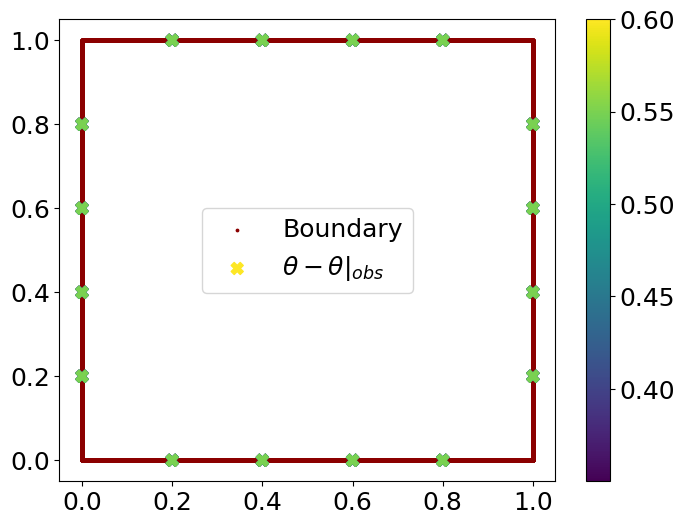

In [16]:
vis = Visualization(cfg,gen, PINN)
vis.plot_obs(save=False,path="")

<Figure size 640x480 with 0 Axes>

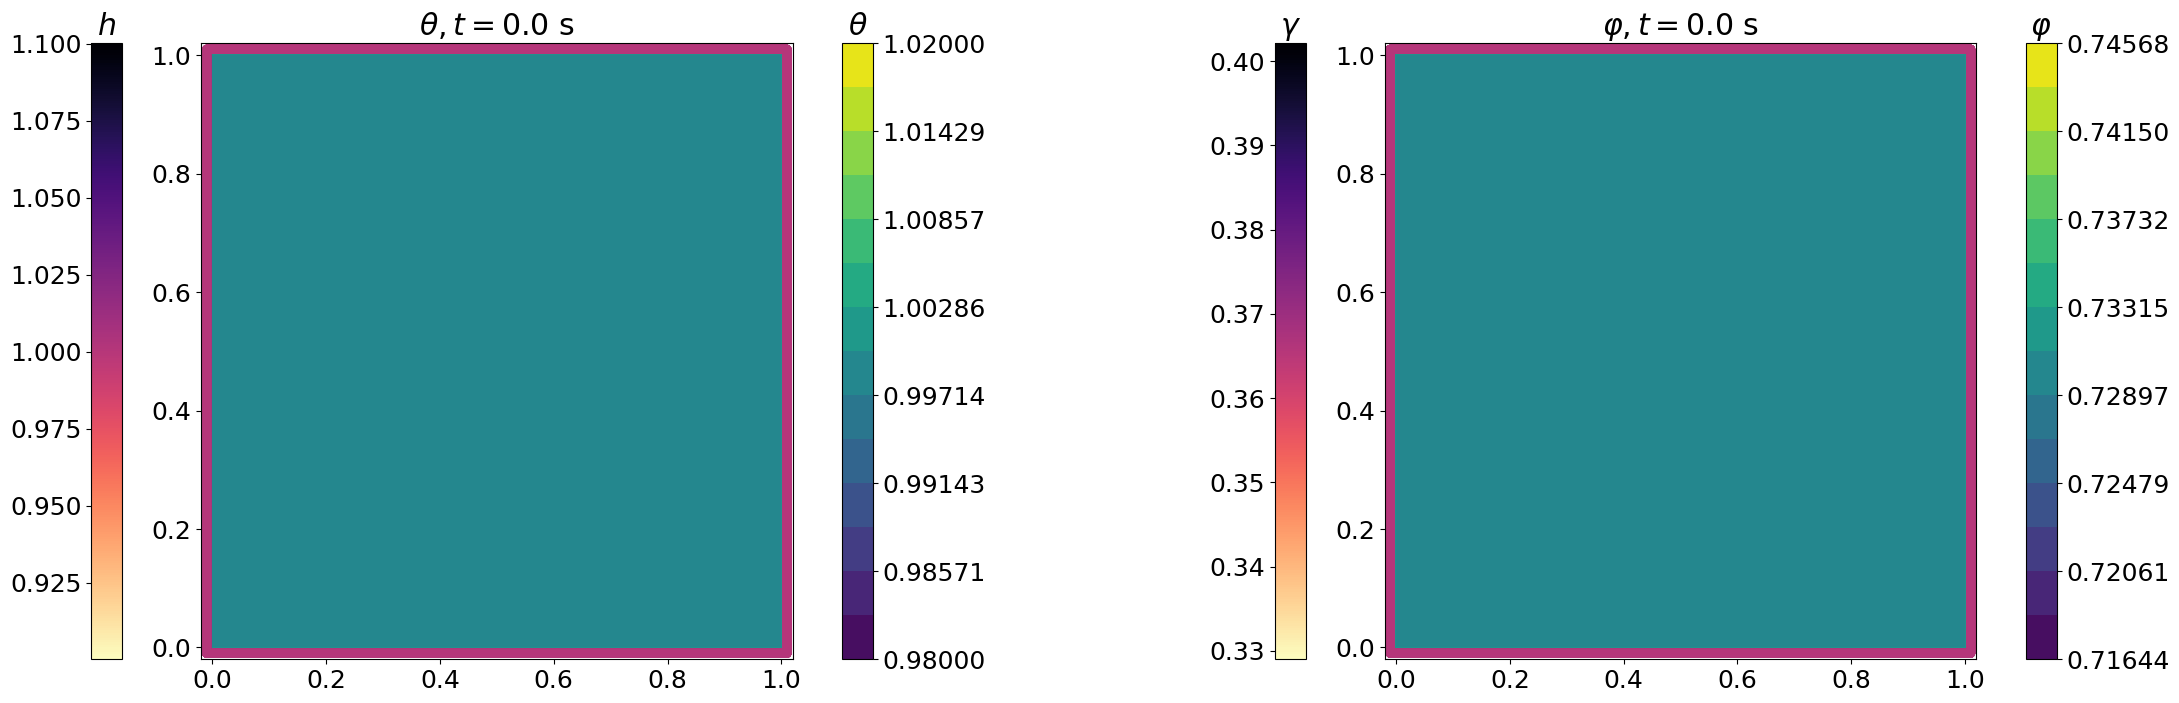

In [17]:
vis.plotu(0.0)

In [18]:
train = Train(cfg,gen,pde, PINN,vis)

C:\Users\Voland\anaconda3\envs\new\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


It: 0 Time: 102.81277275085449 loss_w: 1.83432 loss: 1.60140324 J 0.232916668


<Figure size 640x480 with 0 Axes>

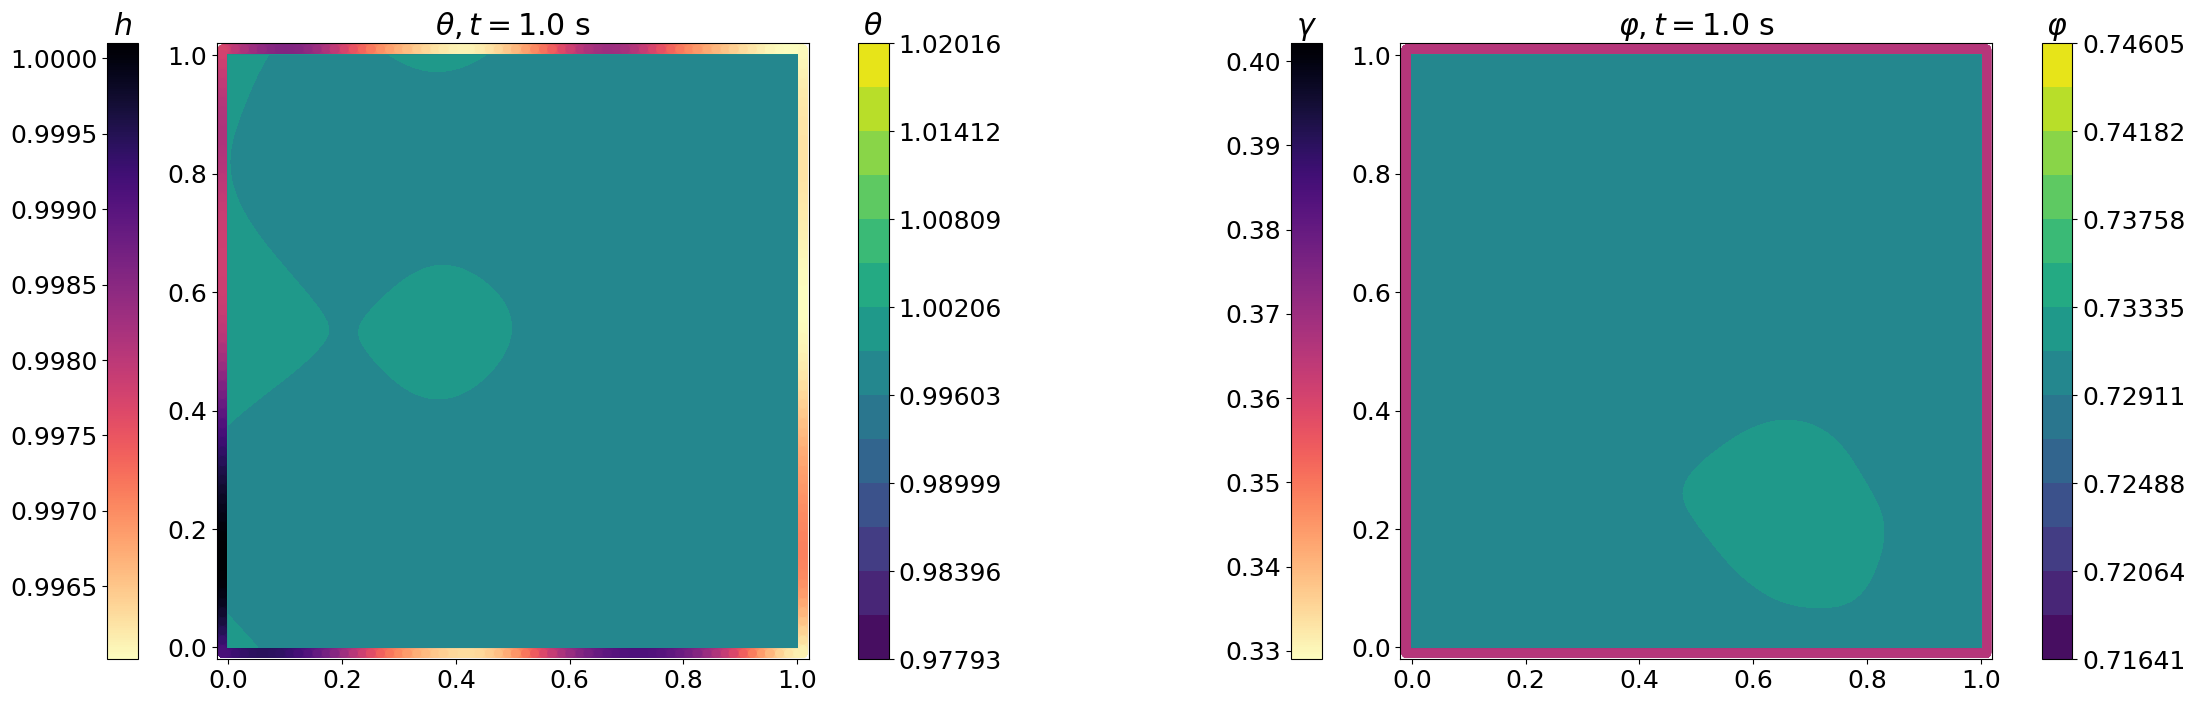

It: 50 Time: 7.390420436859131 loss_w: 1.05071759 loss: 0.837904 J 0.180442676
It: 100 Time: 5.249237537384033 loss_w: 0.816619098 loss: 0.598902285 J 0.171716809
It: 150 Time: 5.281648874282837 loss_w: 0.740283132 loss: 0.512173831 J 0.169443905
It: 200 Time: 5.250783681869507 loss_w: 0.709090352 loss: 0.47322166 J 0.164805874
It: 250 Time: 5.296046257019043 loss_w: 0.658422768 loss: 0.413955867 J 0.169523478
It: 300 Time: 5.329305171966553 loss_w: 0.571048915 loss: 0.329652518 J 0.17413266
It: 350 Time: 5.374665260314941 loss_w: 0.439780712 loss: 0.219019651 J 0.172368929
It: 400 Time: 5.453023195266724 loss_w: 0.295214593 loss: 0.103105515 J 0.168439582
It: 450 Time: 5.500698804855347 loss_w: 0.203805268 loss: 0.0372834 J 0.157321751
It: 500 Time: 5.530671119689941 loss_w: 0.159188166 loss: 0.0197386295 J 0.134236678
It: 550 Time: 5.671834230422974 loss_w: 0.128249809 loss: 0.0141550526 J 0.110398263
It: 600 Time: 5.881605386734009 loss_w: 0.109890588 loss: 0.0126933614 J 0.09388298

<Figure size 640x480 with 0 Axes>

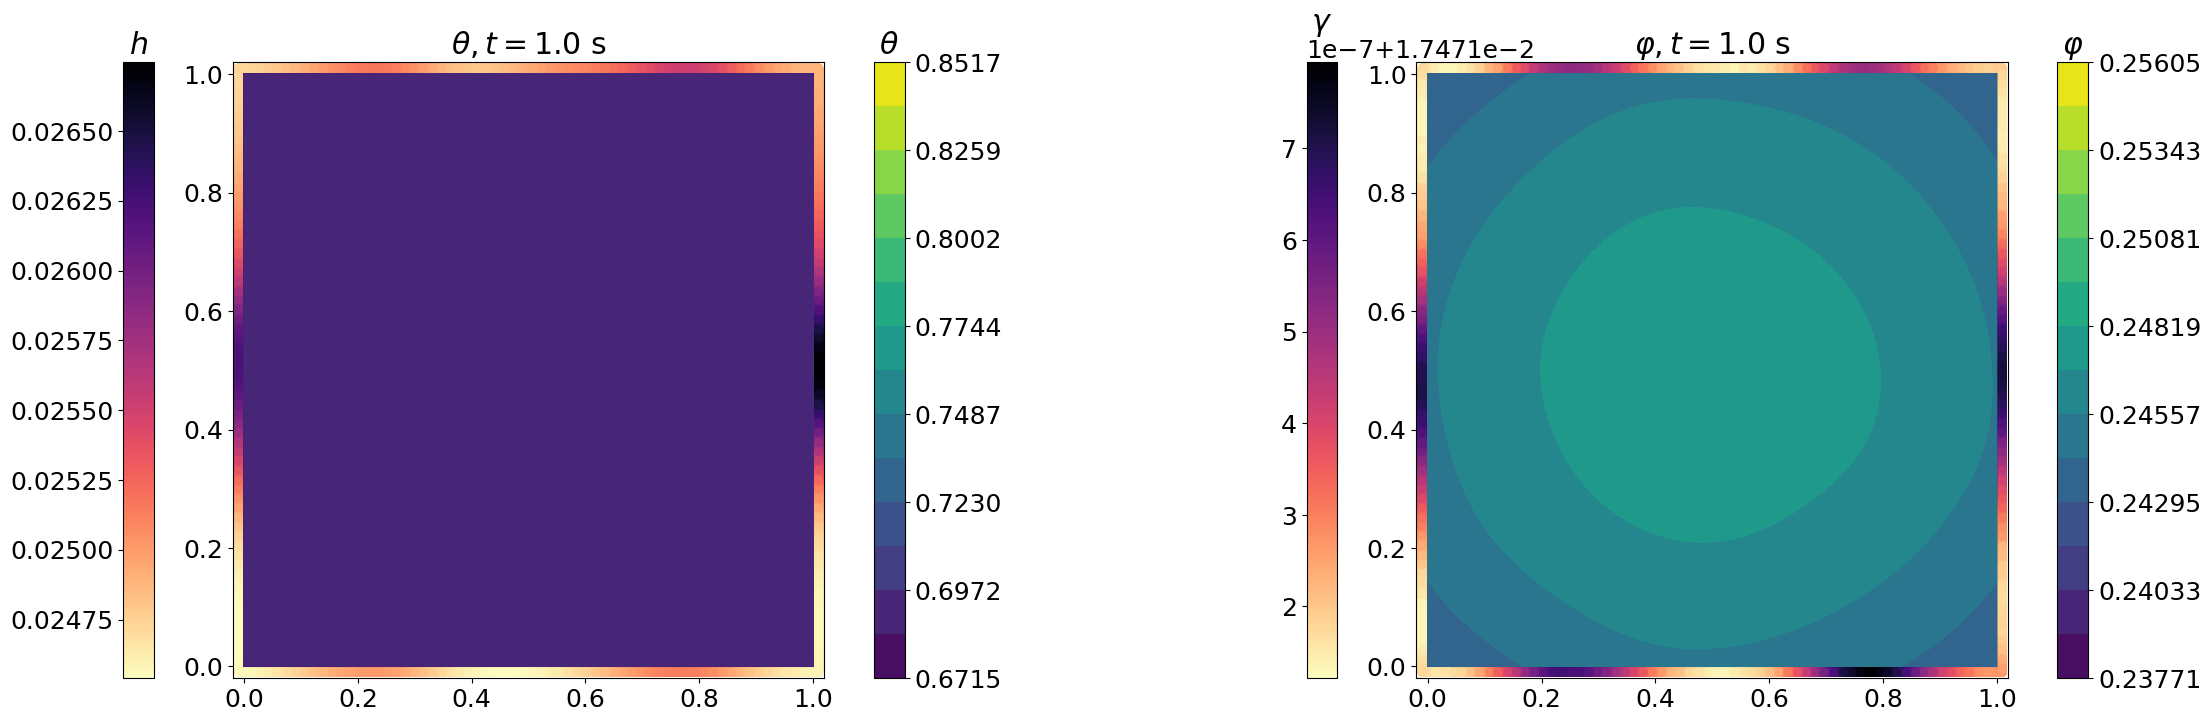

It: 1050 Time: 8.323132276535034 loss_w: 0.0598906353 loss: 0.0190362204 J 0.0315478928
It: 1100 Time: 5.94907808303833 loss_w: 0.0573746711 loss: 0.0191317461 J 0.0282819327
It: 1150 Time: 5.957514762878418 loss_w: 0.0554605126 loss: 0.0194560196 J 0.0252978932
It: 1200 Time: 5.943583250045776 loss_w: 0.0540559813 loss: 0.0197745711 J 0.0227731112
It: 1250 Time: 5.949727535247803 loss_w: 0.0530175045 loss: 0.0199481305 J 0.0206536446
It: 1300 Time: 5.937498092651367 loss_w: 0.0523257852 loss: 0.0201439019 J 0.0189071875
It: 1350 Time: 5.95575213432312 loss_w: 0.0519082844 loss: 0.0202589519 J 0.0174839497
It: 1400 Time: 5.948620796203613 loss_w: 0.0517014414 loss: 0.0204586554 J 0.0161902662
It: 1450 Time: 5.956801414489746 loss_w: 0.0516273044 loss: 0.0206065923 J 0.0151279271
It: 1500 Time: 5.948251008987427 loss_w: 0.0516122691 loss: 0.0206807237 J 0.0142731639
It: 1550 Time: 5.942426681518555 loss_w: 0.0515944771 loss: 0.0206263345 J 0.0136682466
It: 1600 Time: 5.927793264389038 l

<Figure size 640x480 with 0 Axes>

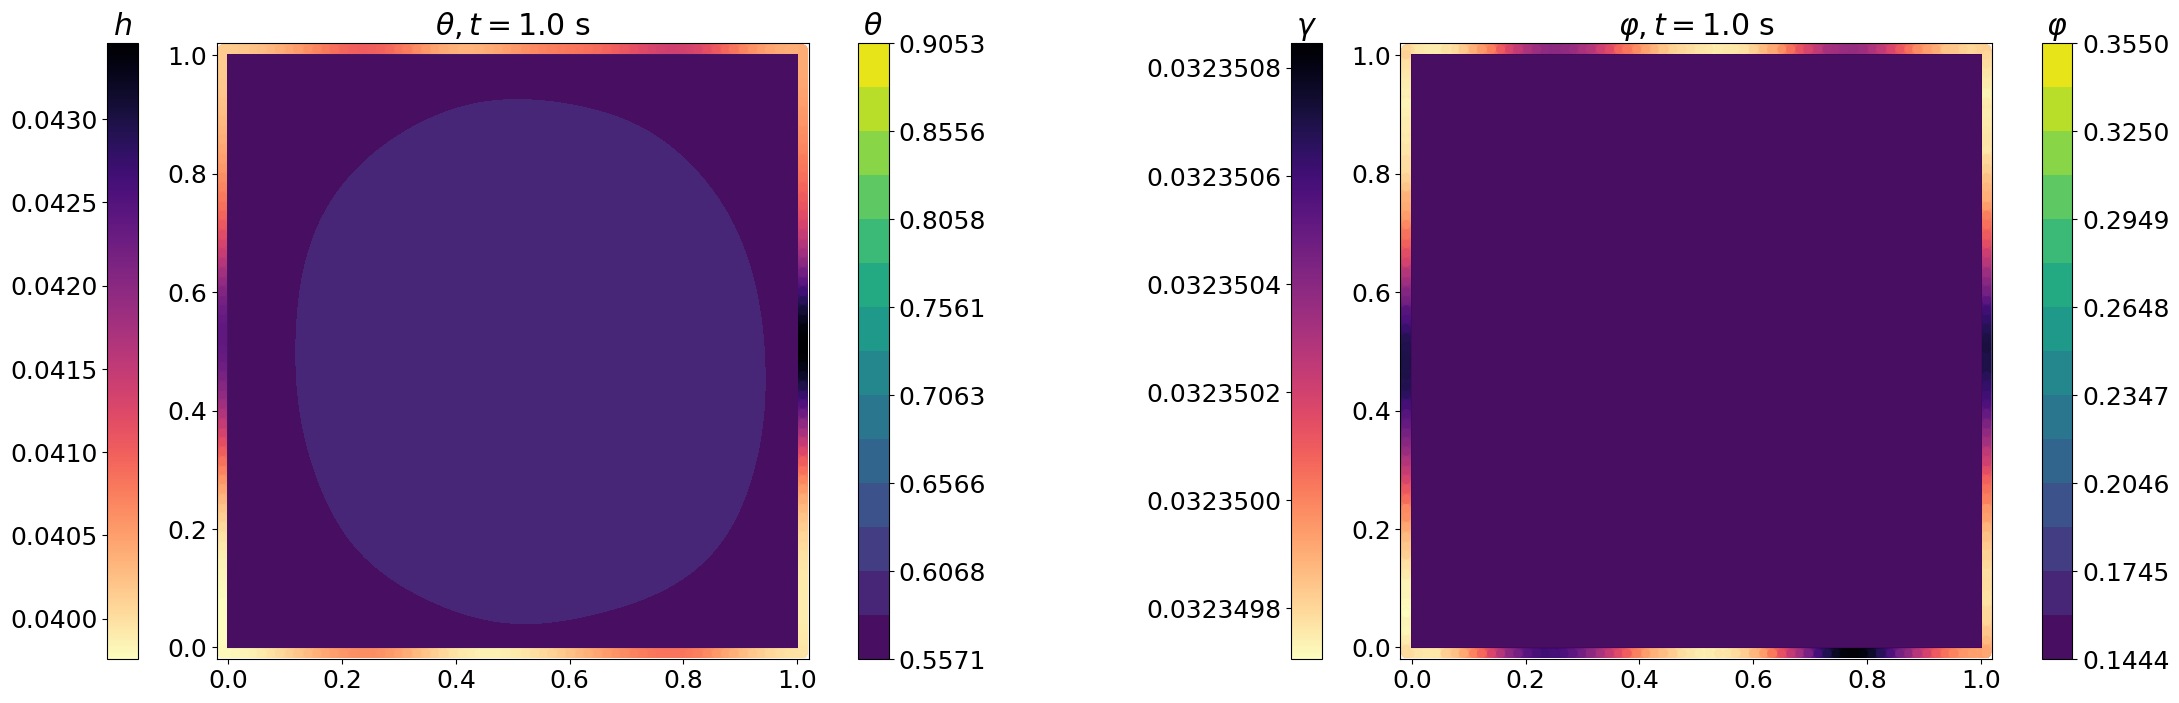

It: 2050 Time: 8.534937381744385 loss_w: 0.0271848813 loss: 0.00998164341 J 0.010796628
It: 2100 Time: 5.943479776382446 loss_w: 0.0230638944 loss: 0.00918337 J 0.0086215781
It: 2150 Time: 6.391902685165405 loss_w: 0.0196556039 loss: 0.00822775345 J 0.0070246025
It: 2200 Time: 6.449387311935425 loss_w: 0.0167657118 loss: 0.007089213 J 0.00610780902
It: 2250 Time: 6.454140901565552 loss_w: 0.0140577 loss: 0.00573369907 J 0.00549961487
It: 2300 Time: 6.453596591949463 loss_w: 0.0116399471 loss: 0.0044089905 J 0.00500247115
It: 2350 Time: 6.472789764404297 loss_w: 0.00977164228 loss: 0.00354546099 J 0.00443220837
It: 2400 Time: 6.456789970397949 loss_w: 0.00823652558 loss: 0.00307169277 J 0.00364703615
It: 2450 Time: 6.476556301116943 loss_w: 0.0069899587 loss: 0.00277859671 J 0.00288373628
It: 2500 Time: 6.472508192062378 loss_w: 0.00594372395 loss: 0.00240394496 J 0.00239680149
It: 2550 Time: 6.50614070892334 loss_w: 0.0049628932 loss: 0.00192853599 J 0.00209578336
It: 2600 Time: 6.7229

<Figure size 640x480 with 0 Axes>

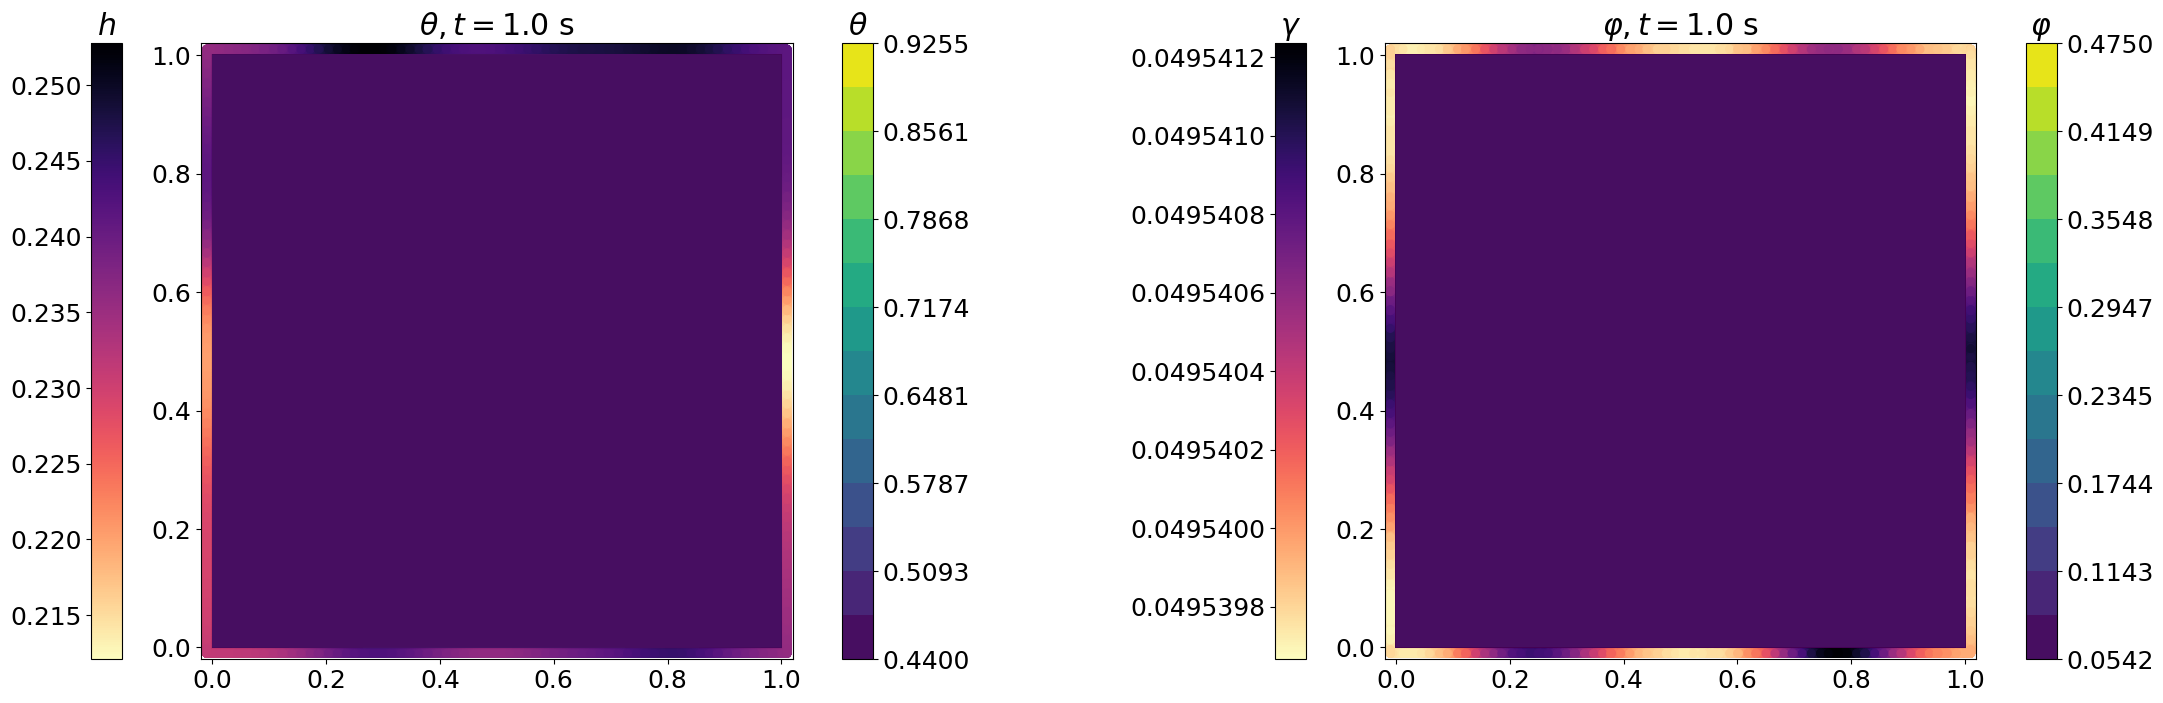

It: 3050 Time: 8.630891561508179 loss_w: 0.00206995499 loss: 0.000676447933 J 0.000992912217
It: 3100 Time: 6.260853052139282 loss_w: 0.00200682739 loss: 0.000639034144 J 0.000988495653
It: 3150 Time: 6.211013317108154 loss_w: 0.00195122138 loss: 0.000612691045 J 0.000975050731
It: 3200 Time: 6.2383952140808105 loss_w: 0.00190100668 loss: 0.000595180318 J 0.000953515
It: 3250 Time: 6.299592733383179 loss_w: 0.00185581576 loss: 0.000581801578 J 0.000930598879
It: 3300 Time: 6.302932262420654 loss_w: 0.00181474281 loss: 0.000567825278 J 0.000912299613
It: 3350 Time: 6.309369087219238 loss_w: 0.00177737628 loss: 0.000552114681 J 0.000900196435
It: 3400 Time: 6.304868698120117 loss_w: 0.0017418908 loss: 0.000536045933 J 0.00089046912
It: 3450 Time: 6.325005054473877 loss_w: 0.00171024015 loss: 0.000520787318 J 0.000883365
It: 3500 Time: 6.483971357345581 loss_w: 0.00168100127 loss: 0.000507339893 J 0.000875935424
It: 3550 Time: 7.531089544296265 loss_w: 0.00165351026 loss: 0.000495688524 J

<Figure size 640x480 with 0 Axes>

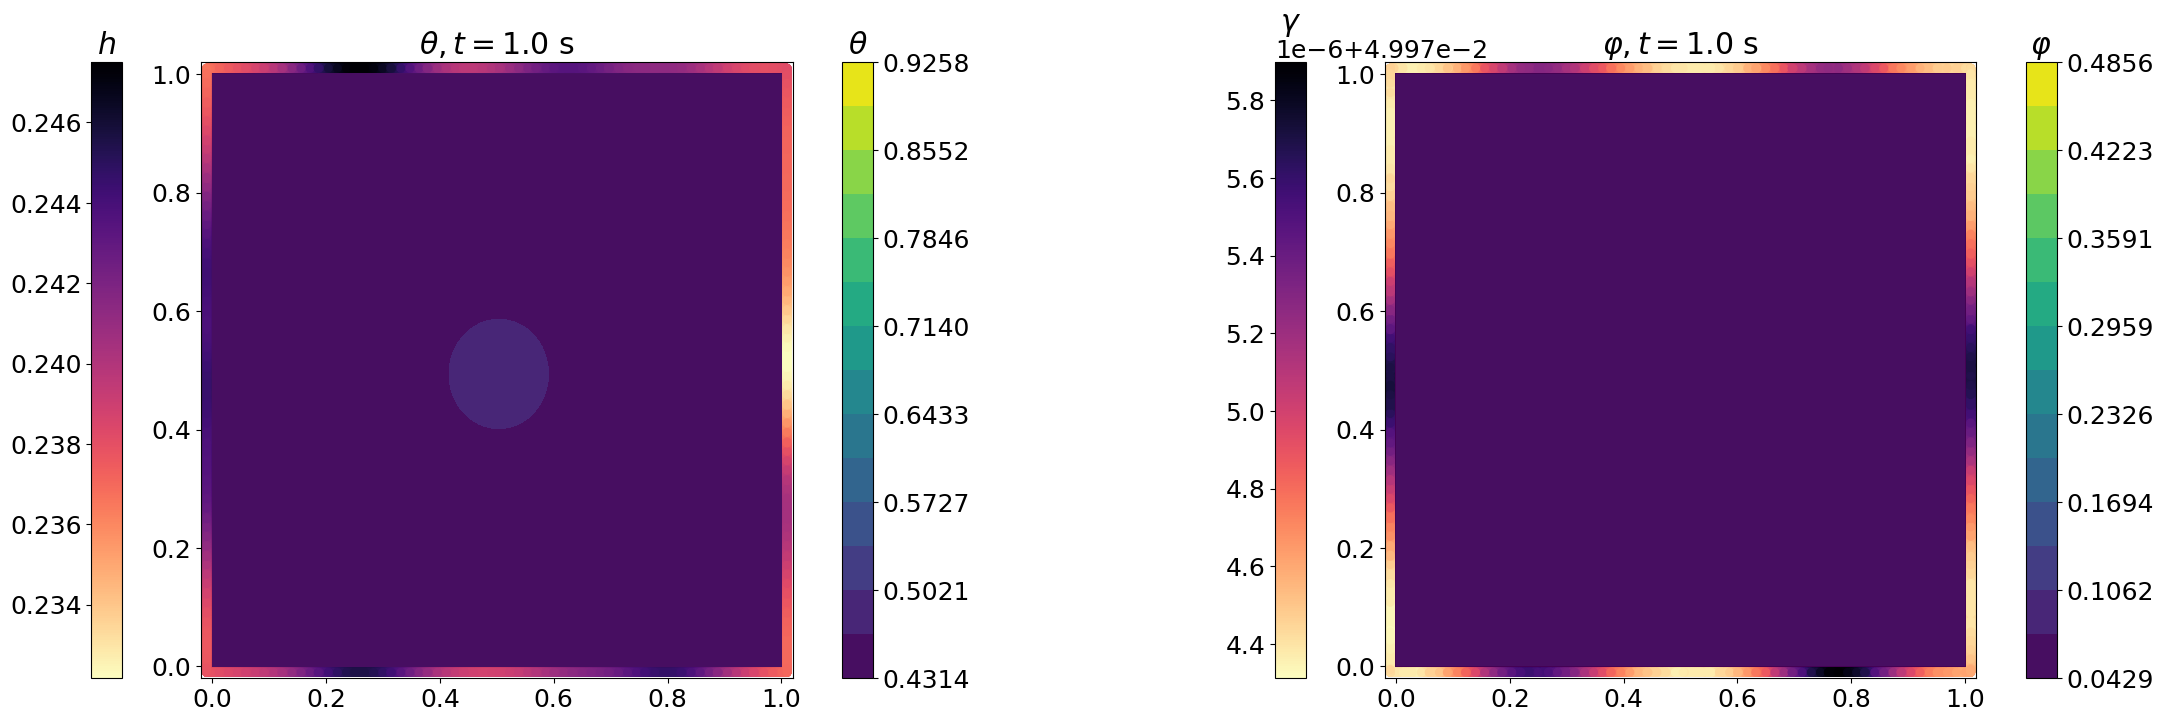

It: 4050 Time: 8.640706539154053 loss_w: 0.00146196701 loss: 0.000412466412 J 0.000810333586
It: 4100 Time: 5.96860408782959 loss_w: 0.00144941639 loss: 0.000406989479 J 0.000806605851
It: 4150 Time: 5.949707984924316 loss_w: 0.00143700093 loss: 0.000402126723 J 0.000802087307
It: 4200 Time: 5.943874359130859 loss_w: 0.00142654101 loss: 0.000397546741 J 0.000799120171
It: 4250 Time: 5.938807964324951 loss_w: 0.00141643011 loss: 0.000393506314 J 0.000795584172
It: 4300 Time: 5.9851393699646 loss_w: 0.00140631071 loss: 0.000389610592 J 0.000791830185
It: 4350 Time: 6.003791332244873 loss_w: 0.00139706861 loss: 0.000385847583 J 0.000788677309
It: 4400 Time: 6.098149538040161 loss_w: 0.00138820976 loss: 0.000382554135 J 0.00078523095
It: 4450 Time: 6.043088436126709 loss_w: 0.0013803083 loss: 0.000379365752 J 0.000782487739
It: 4500 Time: 6.078109502792358 loss_w: 0.0013729285 loss: 0.000376529555 J 0.000779711583
It: 4550 Time: 6.050149917602539 loss_w: 0.0013664295 loss: 0.000373907678 J

<Figure size 640x480 with 0 Axes>

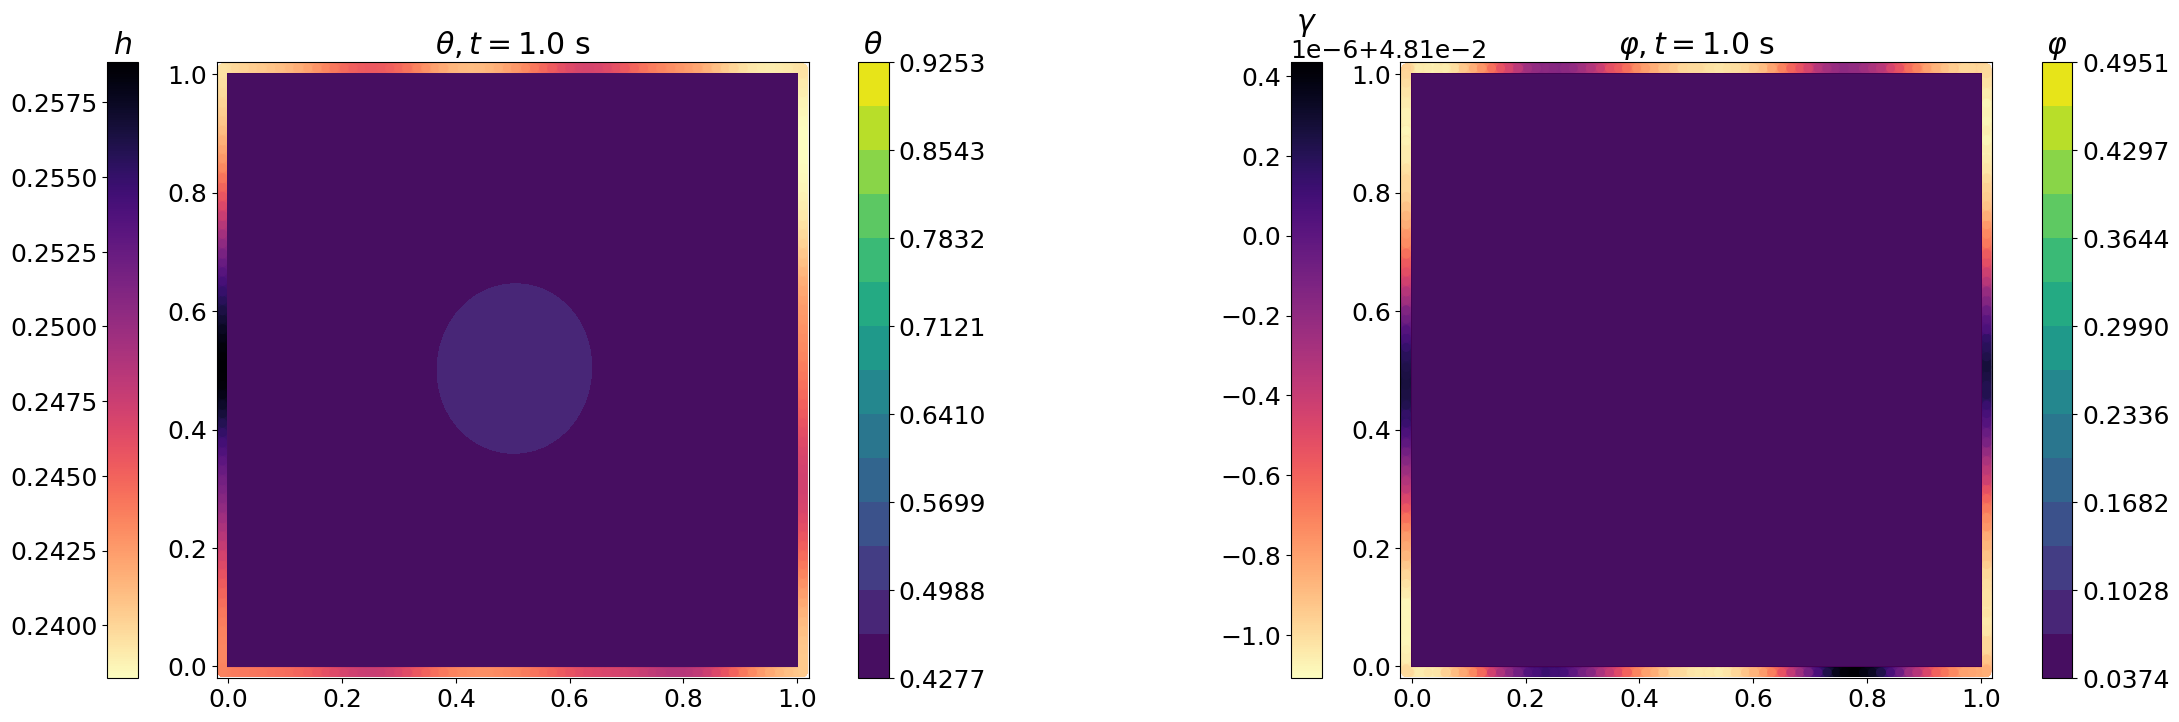

It: 5050 Time: 8.408688068389893 loss_w: 0.00131329708 loss: 0.000353389856 J 0.000757860951
It: 5100 Time: 6.012651443481445 loss_w: 0.00130906305 loss: 0.000351591181 J 0.000756467052
It: 5150 Time: 5.967203378677368 loss_w: 0.00130471215 loss: 0.000349987647 J 0.000754752487
It: 5200 Time: 5.780869960784912 loss_w: 0.00130087673 loss: 0.000348300557 J 0.000753572909
It: 5250 Time: 5.755488395690918 loss_w: 0.00129817473 loss: 0.000347169058 J 0.000752620224
It: 5300 Time: 5.802187442779541 loss_w: 0.00129430718 loss: 0.000345485052 J 0.000751522544
It: 5350 Time: 5.909670114517212 loss_w: 0.00128990808 loss: 0.000343724096 J 0.000749870145
It: 5400 Time: 5.918820858001709 loss_w: 0.00128618465 loss: 0.000341879029 J 0.000749045576
It: 5450 Time: 5.911363124847412 loss_w: 0.00128355785 loss: 0.000340499857 J 0.000748580263
It: 5500 Time: 5.914141416549683 loss_w: 0.00127991883 loss: 0.000338853948 J 0.000747478625
It: 5550 Time: 5.819535970687866 loss_w: 0.00127720414 loss: 0.0003372

<Figure size 640x480 with 0 Axes>

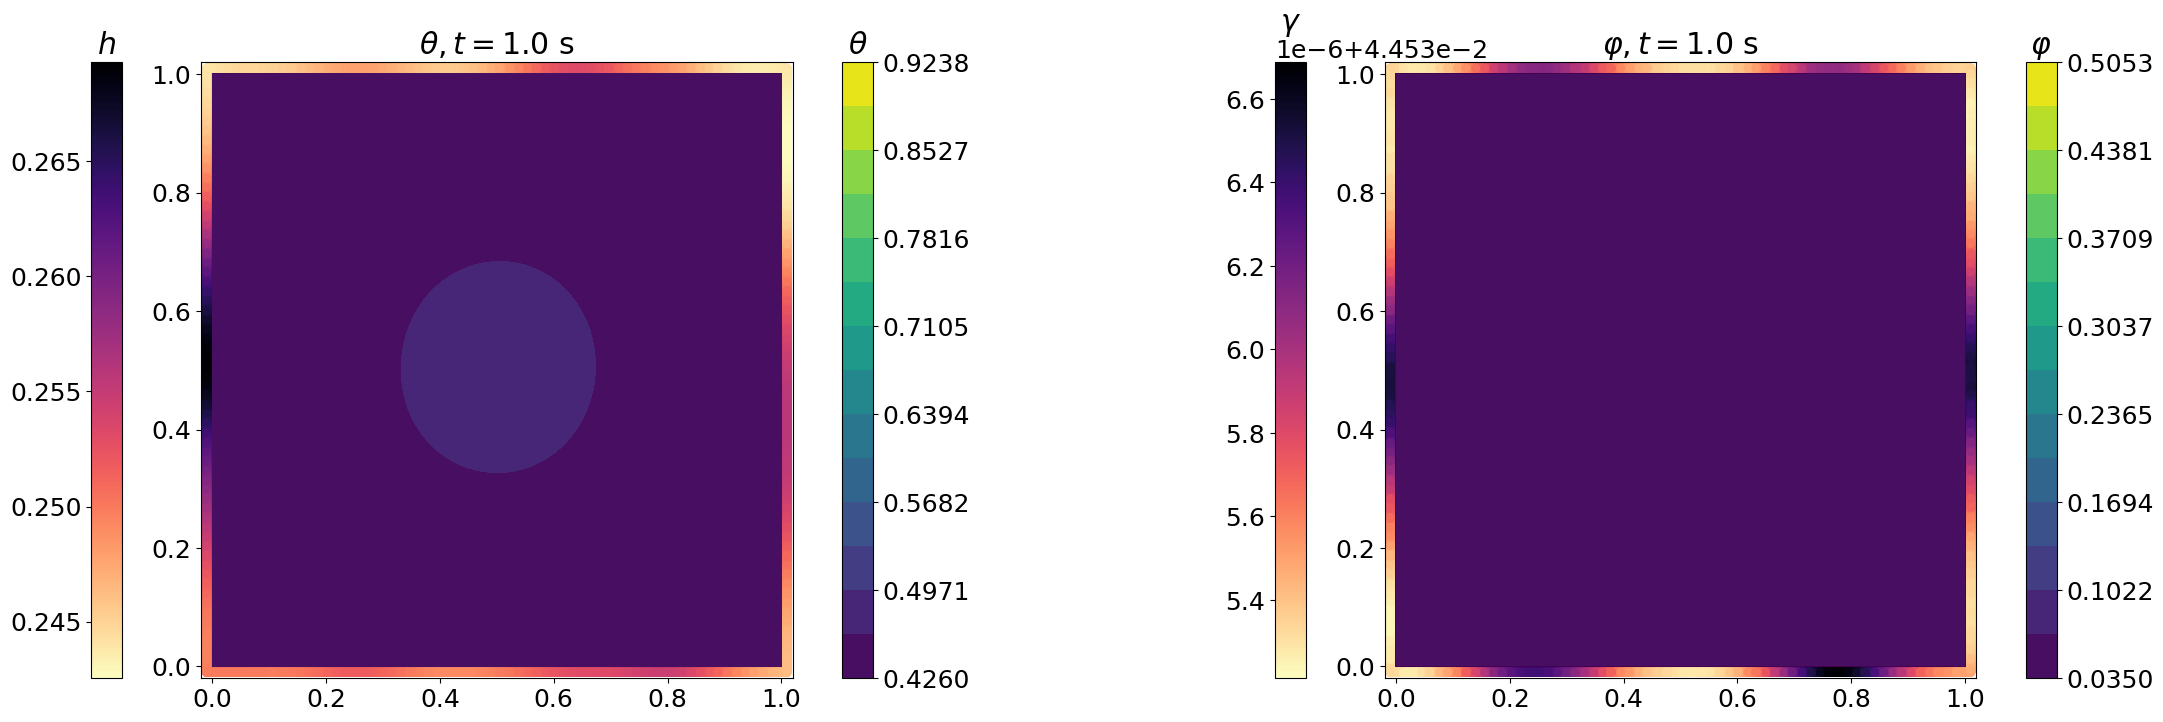

It: 6050 Time: 8.02396035194397 loss_w: 0.00124693767 loss: 0.00032164171 J 0.000740786782
It: 6100 Time: 5.715437889099121 loss_w: 0.00124369864 loss: 0.000320308696 J 0.000739537878
It: 6150 Time: 5.84157395362854 loss_w: 0.00124090363 loss: 0.000318777544 J 0.000739019772
It: 6200 Time: 5.759862661361694 loss_w: 0.00123822829 loss: 0.000317104685 J 0.000738782168
It: 6250 Time: 5.791848421096802 loss_w: 0.00123577332 loss: 0.000315728277 J 0.000738453527
It: 6300 Time: 5.758736848831177 loss_w: 0.00123307295 loss: 0.000313906028 J 0.000738433795
It: 6350 Time: 5.8395421504974365 loss_w: 0.00122974534 loss: 0.000312281394 J 0.000737506431
It: 6400 Time: 5.825146436691284 loss_w: 0.00122708117 loss: 0.000310772972 J 0.000737055903
It: 6450 Time: 5.94942569732666 loss_w: 0.00122439722 loss: 0.000309182913 J 0.000736696878
It: 6500 Time: 5.934037923812866 loss_w: 0.00122167682 loss: 0.00030771413 J 0.00073609734
It: 6550 Time: 5.880046367645264 loss_w: 0.00121854781 loss: 0.000305816939

<Figure size 640x480 with 0 Axes>

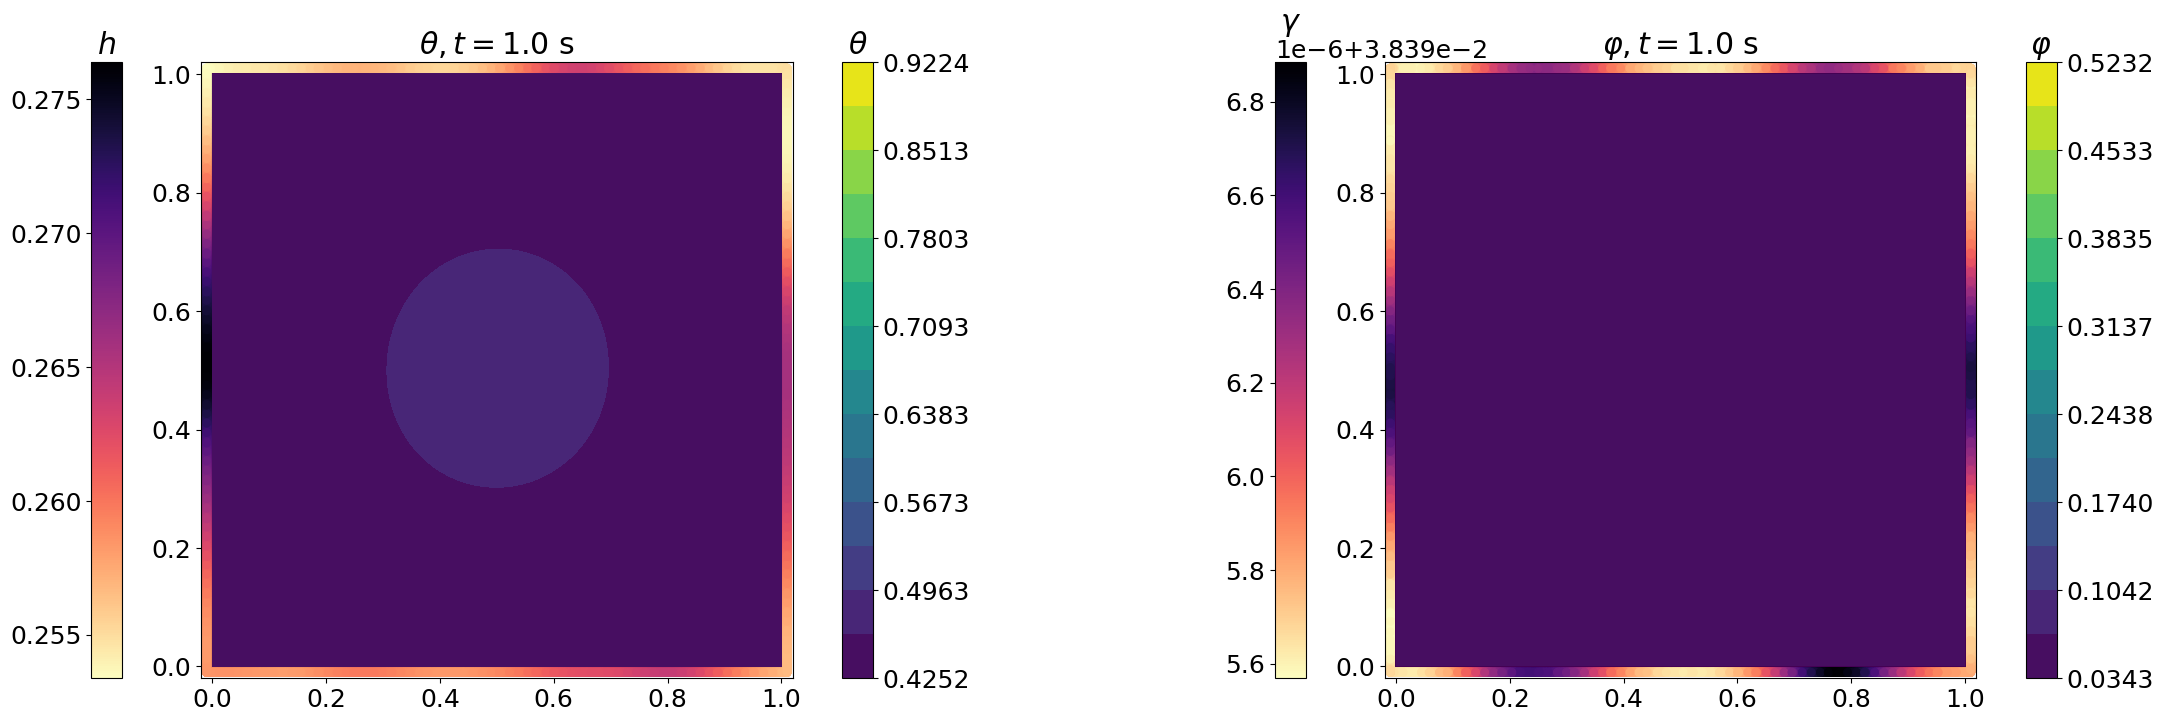

It: 7050 Time: 8.120275259017944 loss_w: 0.00119189511 loss: 0.000289932912 J 0.000731724082
It: 7100 Time: 5.817834854125977 loss_w: 0.00118941208 loss: 0.000288552576 J 0.00073113566
It: 7150 Time: 5.83759331703186 loss_w: 0.00118645665 loss: 0.000286792871 J 0.000730623782
It: 7200 Time: 5.905534505844116 loss_w: 0.00118439645 loss: 0.000285466027 J 0.000730352884
It: 7250 Time: 5.942070007324219 loss_w: 0.00118149247 loss: 0.00028370315 J 0.000729885476
It: 7300 Time: 6.034205675125122 loss_w: 0.00117872469 loss: 0.000281936169 J 0.000729560619
It: 7350 Time: 6.059508562088013 loss_w: 0.00117638754 loss: 0.000280637149 J 0.000728913117
It: 7400 Time: 5.832799911499023 loss_w: 0.00117398682 loss: 0.000278906489 J 0.000728856074
It: 7450 Time: 5.768941640853882 loss_w: 0.00117101008 loss: 0.000277655345 J 0.00072752242
It: 7500 Time: 6.065383434295654 loss_w: 0.0011692571 loss: 0.000276359584 J 0.000727404084
It: 7550 Time: 6.136142253875732 loss_w: 0.00116639759 loss: 0.000274403777

<Figure size 640x480 with 0 Axes>

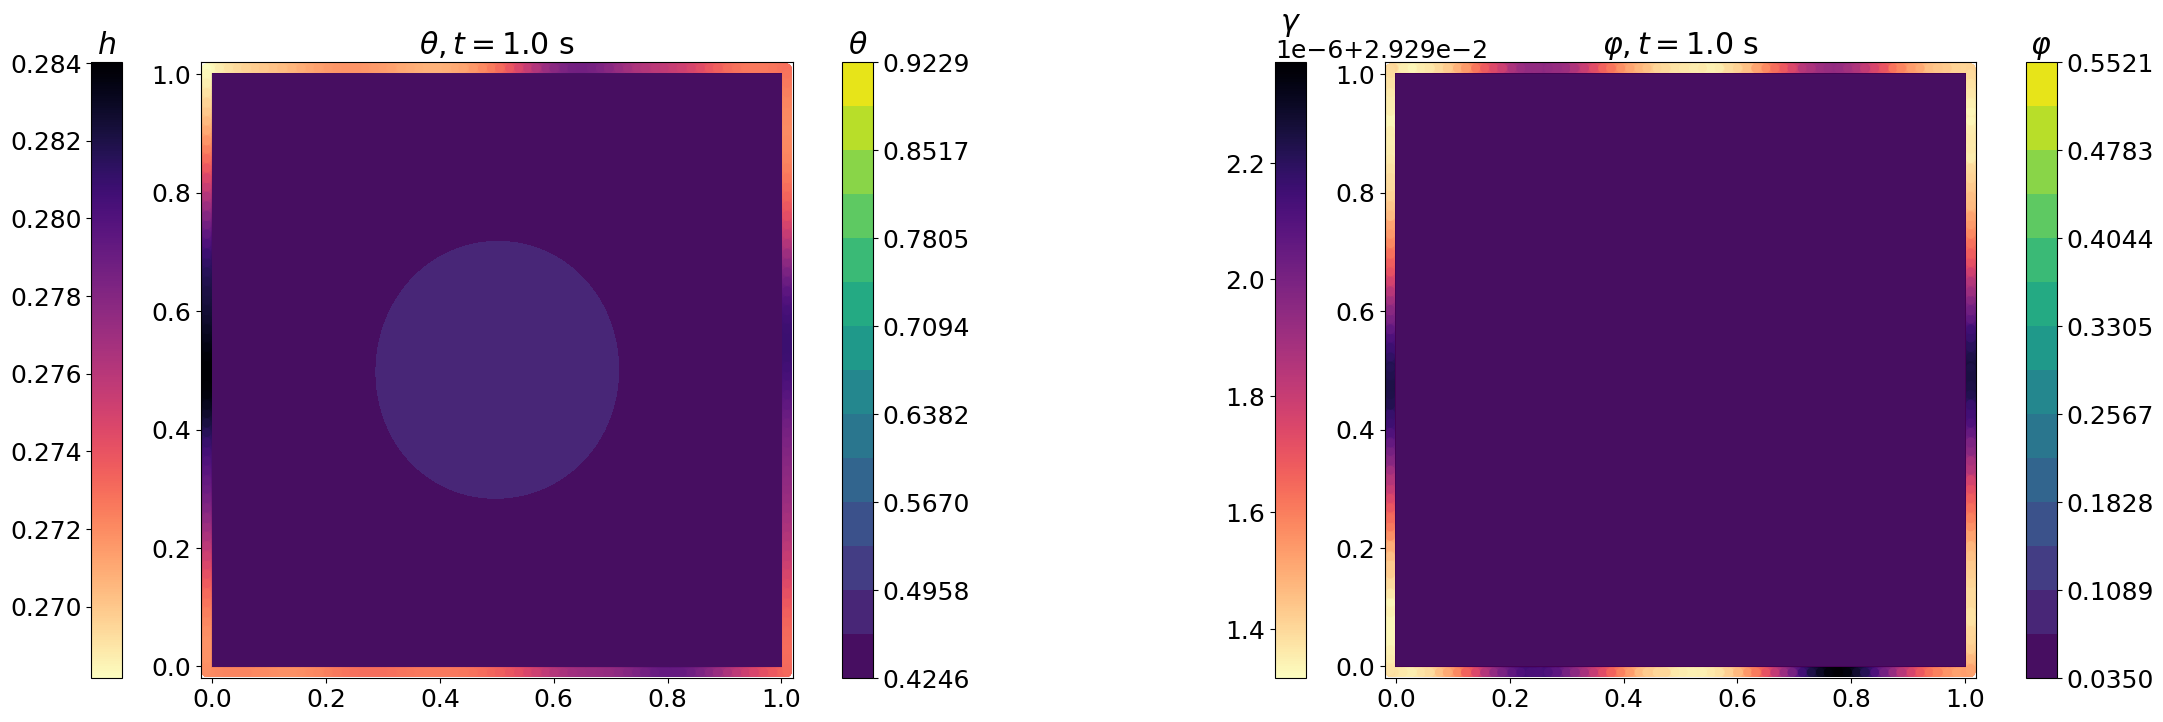

It: 8050 Time: 8.24904465675354 loss_w: 0.00114237308 loss: 0.000259556342 J 0.000721622899
It: 8100 Time: 5.877753019332886 loss_w: 0.00114057527 loss: 0.00025801055 J 0.000721677206
It: 8150 Time: 5.882814884185791 loss_w: 0.0011380997 loss: 0.000256493047 J 0.000721007294
It: 8200 Time: 5.928501605987549 loss_w: 0.00113546441 loss: 0.000254967628 J 0.00072006759
It: 8250 Time: 5.917200803756714 loss_w: 0.00113380095 loss: 0.000253575272 J 0.000720046053
It: 8300 Time: 6.088120937347412 loss_w: 0.00113120838 loss: 0.000252091588 J 0.000719204487
It: 8350 Time: 6.066064357757568 loss_w: 0.00112917146 loss: 0.000250803 J 0.000718509487
It: 8400 Time: 6.087275981903076 loss_w: 0.00112634921 loss: 0.000249263016 J 0.000717360061
It: 8450 Time: 6.012358903884888 loss_w: 0.00112481345 loss: 0.00024769138 J 0.000717568677
It: 8500 Time: 5.99823522567749 loss_w: 0.00112262007 loss: 0.000246404263 J 0.000716770242
It: 8550 Time: 5.990532398223877 loss_w: 0.00112052425 loss: 0.000244762719 J 0

<Figure size 640x480 with 0 Axes>

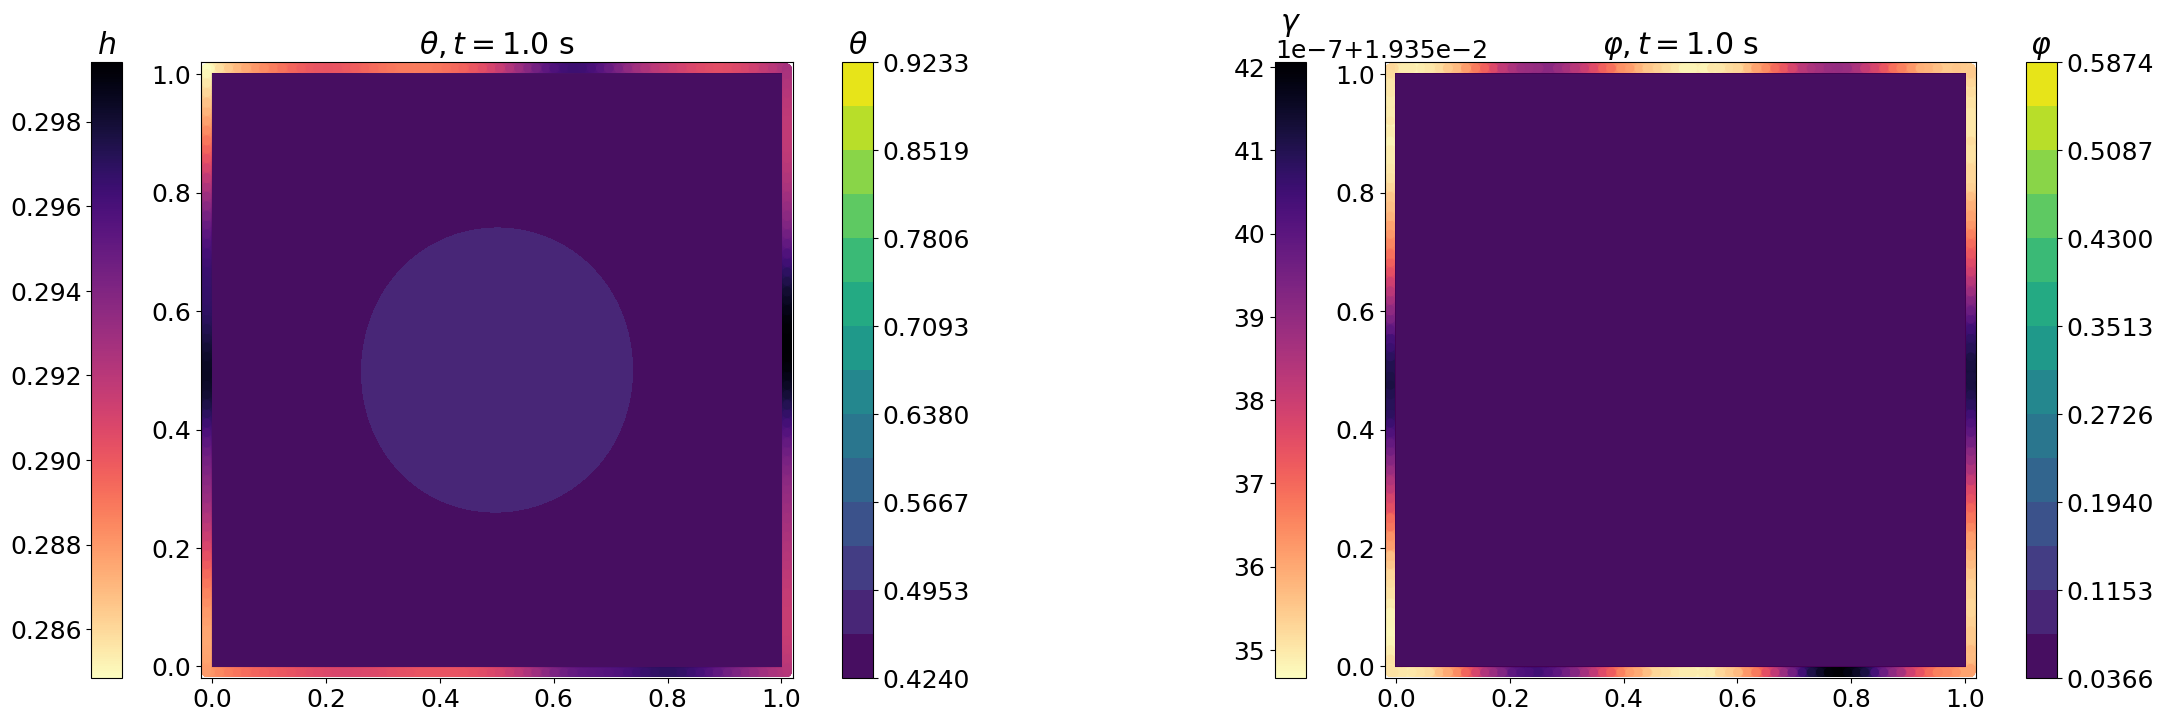

It: 9050 Time: 8.336104393005371 loss_w: 0.00110216415 loss: 0.000232067556 J 0.000710502
It: 9100 Time: 5.981000185012817 loss_w: 0.0011008298 loss: 0.000230452788 J 0.000710891851
It: 9150 Time: 5.904287815093994 loss_w: 0.00109953282 loss: 0.000229439451 J 0.000710372813
It: 9200 Time: 5.9018778800964355 loss_w: 0.00110101944 loss: 0.000230376667 J 0.000709580781
It: 9250 Time: 5.933056354522705 loss_w: 0.00109716714 loss: 0.000227547876 J 0.000709346496
It: 9300 Time: 6.082627058029175 loss_w: 0.00109584932 loss: 0.000226417222 J 0.000708957
It: 9350 Time: 6.033365249633789 loss_w: 0.00109526212 loss: 0.000225419499 J 0.000709142245
It: 9400 Time: 5.985646724700928 loss_w: 0.00109363545 loss: 0.0002239 J 0.00070910668
It: 9450 Time: 5.906623601913452 loss_w: 0.00109243824 loss: 0.000222534451 J 0.000709213782
It: 9500 Time: 5.931056976318359 loss_w: 0.0010904026 loss: 0.00022120848 J 0.000708492
It: 9550 Time: 5.923828125 loss_w: 0.00109498447 loss: 0.000223326 J 0.000708650274
It:

<Figure size 640x480 with 0 Axes>

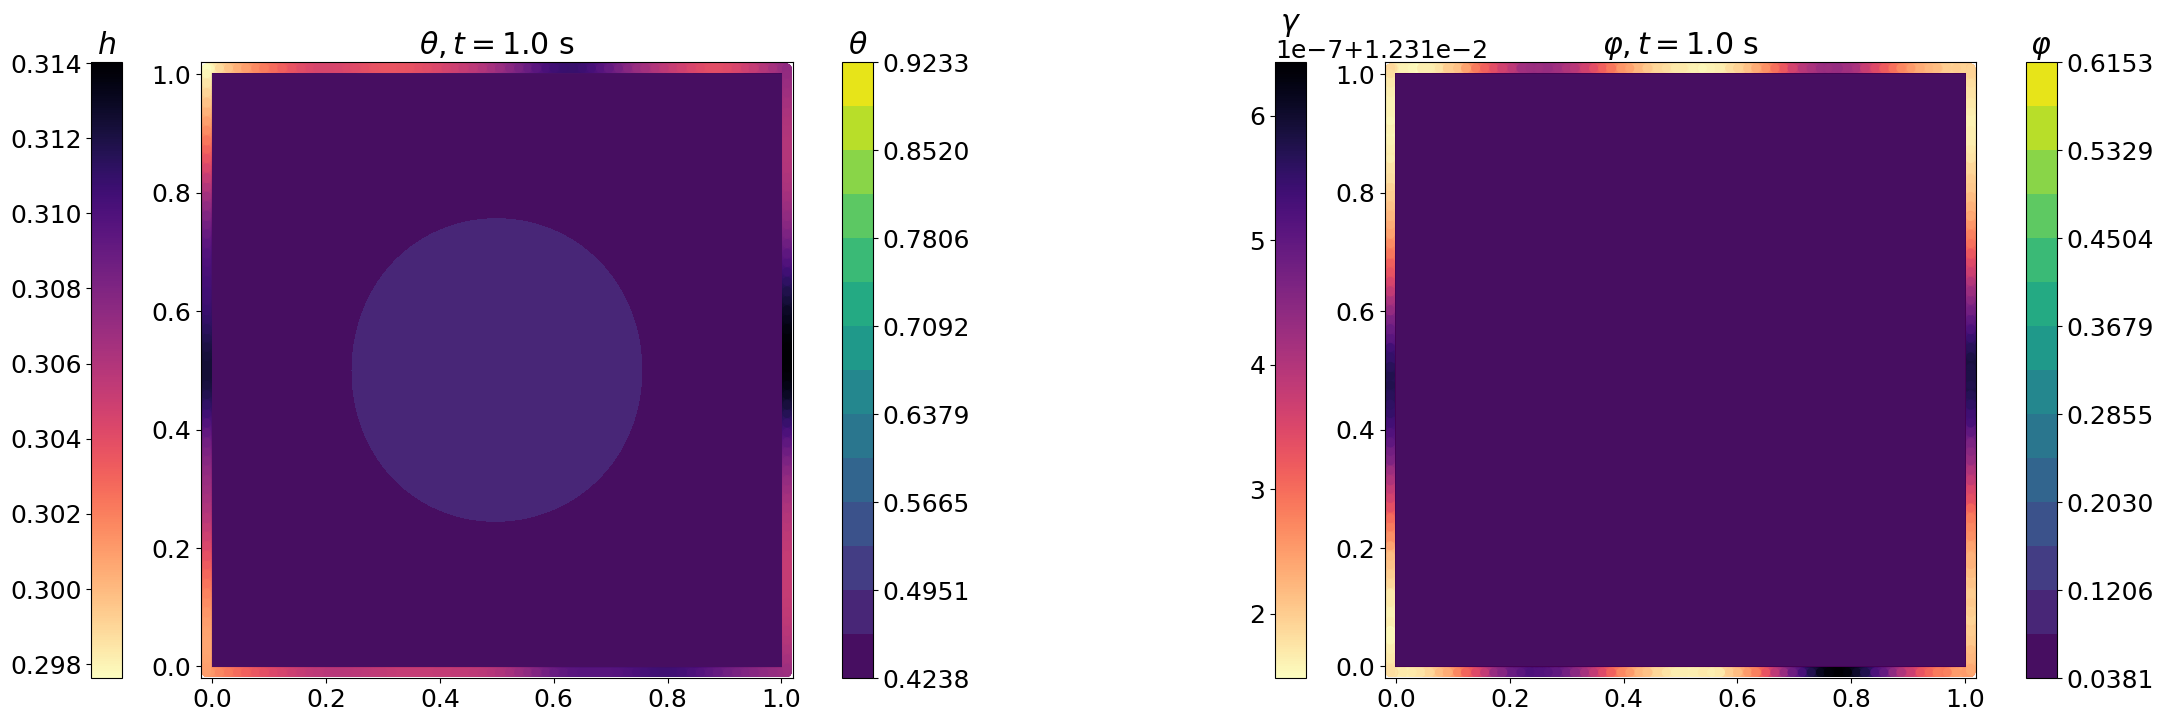

It: 10050 Time: 8.760434627532959 loss_w: 0.00108226237 loss: 0.000210162063 J 0.000708937179
It: 10100 Time: 6.005272150039673 loss_w: 0.00108262163 loss: 0.00020932444 J 0.000709787244
It: 10150 Time: 6.050456762313843 loss_w: 0.00108169974 loss: 0.000208488316 J 0.000709544867
It: 10200 Time: 6.103510141372681 loss_w: 0.00108041917 loss: 0.000206873621 J 0.000709997315
It: 10250 Time: 6.110373020172119 loss_w: 0.00107984408 loss: 0.000205955585 J 0.000710081833
It: 10300 Time: 6.710369348526001 loss_w: 0.00108048844 loss: 0.000205925404 J 0.000710070191
It: 10350 Time: 6.388126611709595 loss_w: 0.00108614704 loss: 0.000208383426 J 0.000711220491
It: 10400 Time: 6.417095184326172 loss_w: 0.0010798825 loss: 0.000203840027 J 0.000711268804
It: 10450 Time: 6.997571706771851 loss_w: 0.00108203944 loss: 0.00020429329 J 0.000712024688
It: 10500 Time: 6.523240327835083 loss_w: 0.00107916549 loss: 0.000201635718 J 0.000712522
It: 10550 Time: 8.30468201637268 loss_w: 0.0010791762 loss: 0.0002

<Figure size 640x480 with 0 Axes>

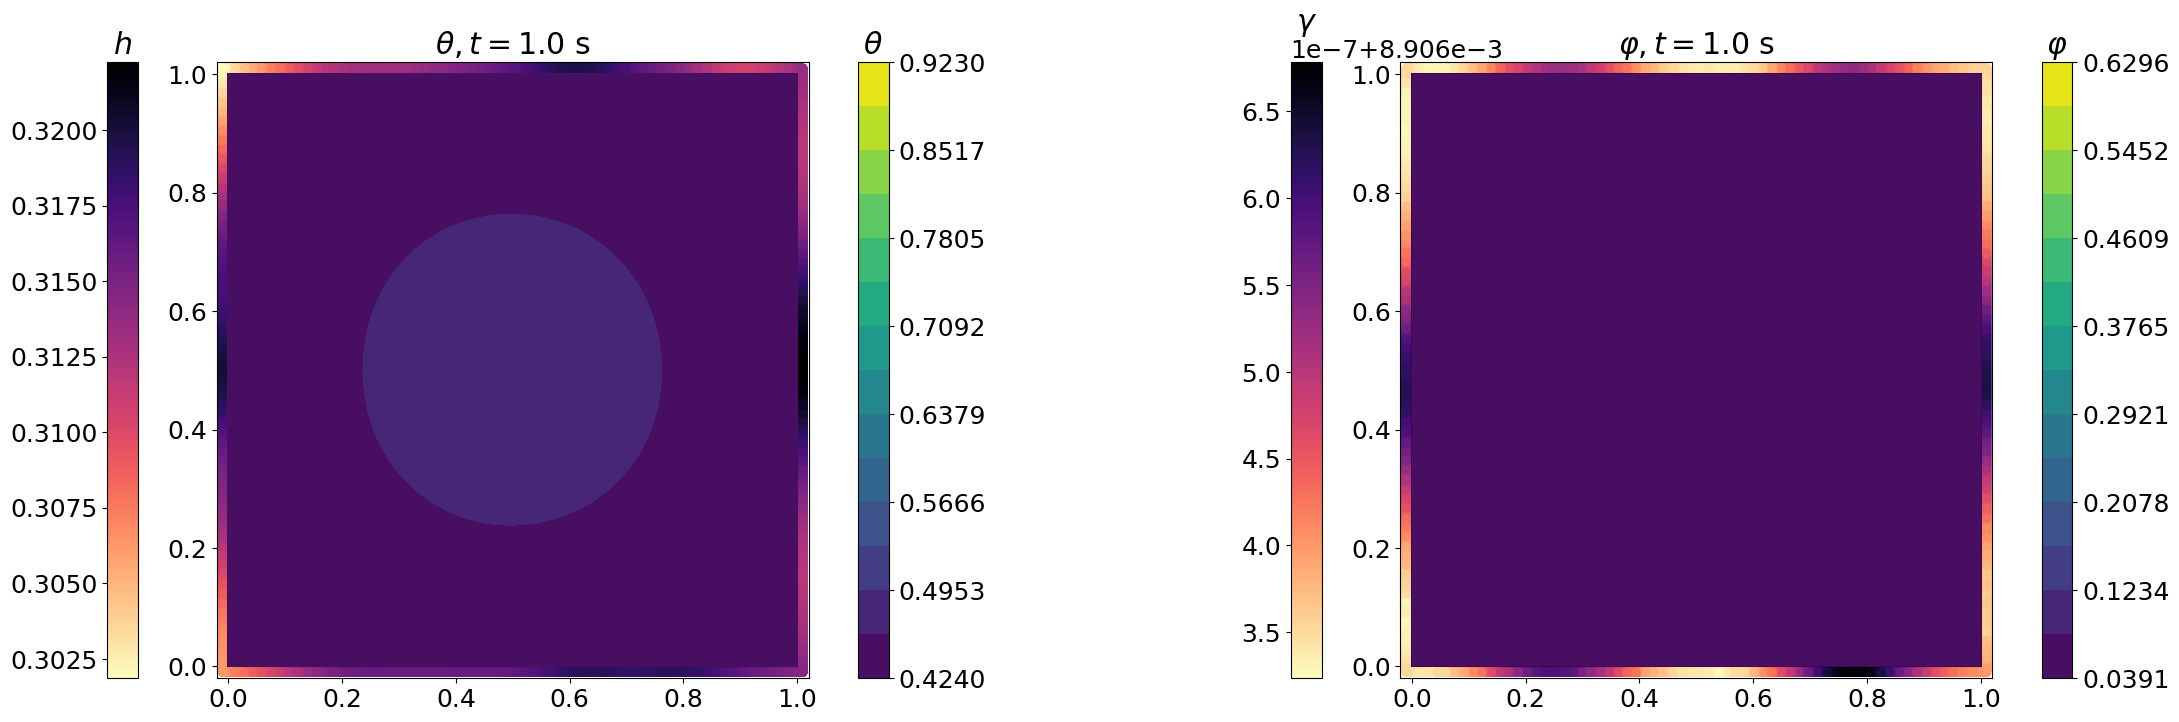

It: 11050 Time: 8.541937351226807 loss_w: 0.00107844488 loss: 0.000191442712 J 0.000720462471
It: 11100 Time: 6.074484348297119 loss_w: 0.00108018075 loss: 0.000191674291 J 0.000721265096
It: 11150 Time: 5.997507810592651 loss_w: 0.0010806598 loss: 0.000191112282 J 0.000721802237
It: 11200 Time: 5.9137489795684814 loss_w: 0.00108734902 loss: 0.000193959539 J 0.000723437
It: 11250 Time: 5.724945783615112 loss_w: 0.00107821263 loss: 0.000187808007 J 0.00072362303
It: 11300 Time: 5.707974433898926 loss_w: 0.00107941625 loss: 0.000187721351 J 0.000724288169
It: 11350 Time: 5.569359540939331 loss_w: 0.00107961893 loss: 0.000186679419 J 0.000725685619
It: 11400 Time: 5.6264307498931885 loss_w: 0.00107911648 loss: 0.000185254277 J 0.000726836442
It: 11450 Time: 5.651206016540527 loss_w: 0.00108059274 loss: 0.000185719007 J 0.000726994767
It: 11500 Time: 5.56290864944458 loss_w: 0.00108229555 loss: 0.000185324359 J 0.000728861953
It: 11550 Time: 5.5287675857543945 loss_w: 0.00108318415 loss: 0

<Figure size 640x480 with 0 Axes>

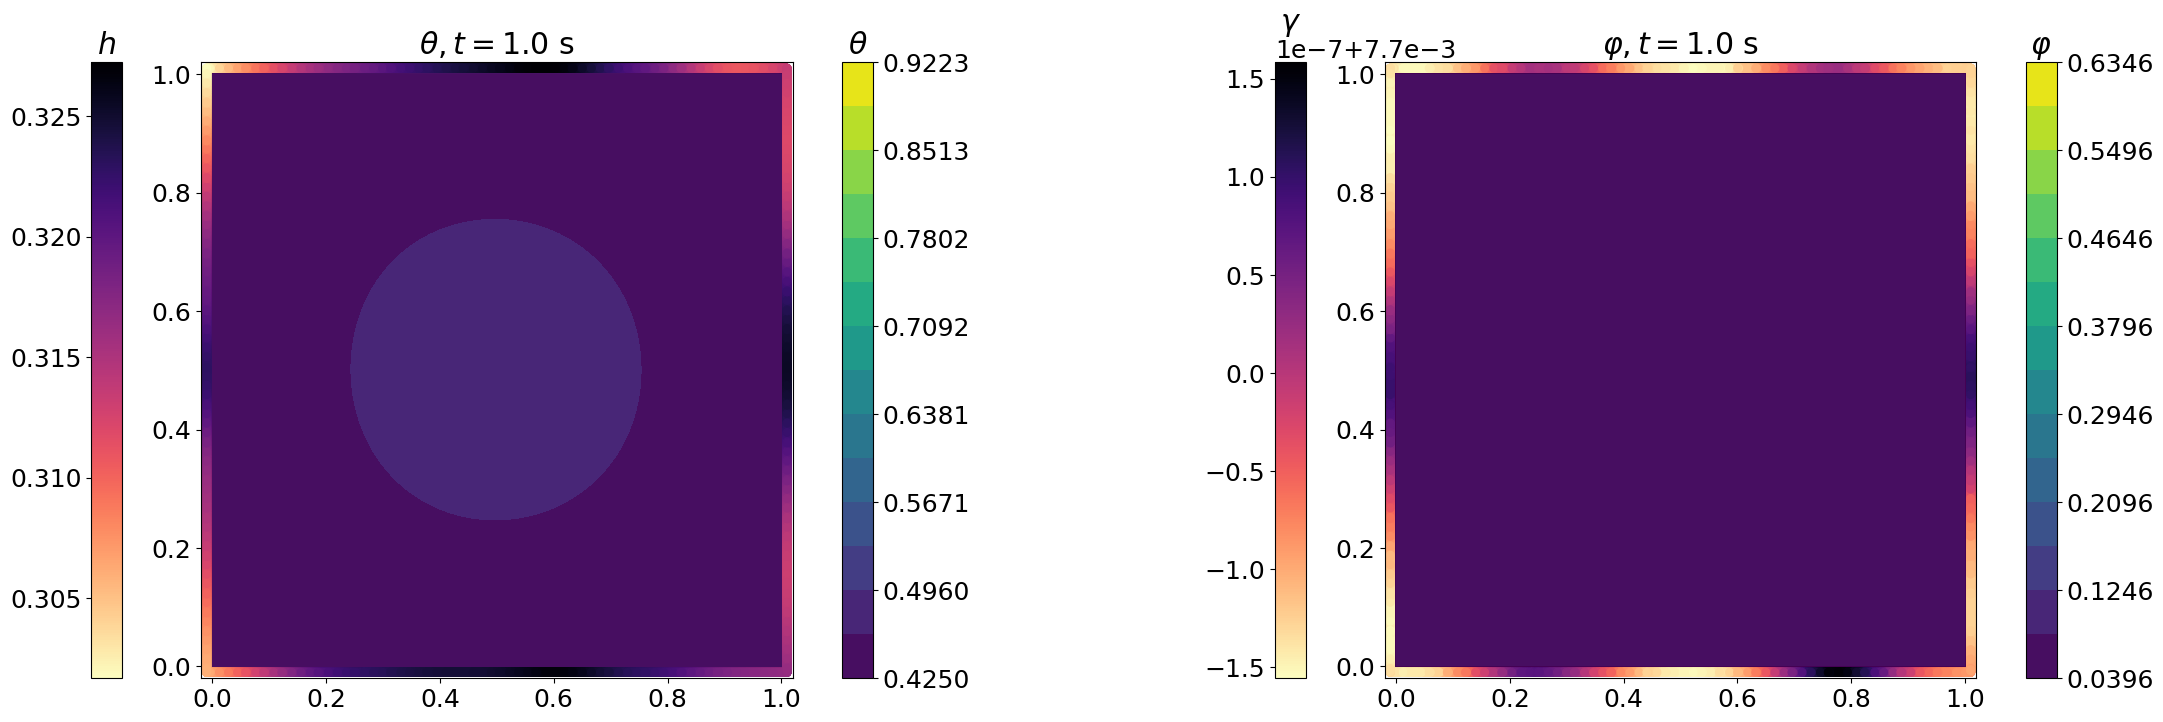

It: 12050 Time: 7.997328042984009 loss_w: 0.00108387682 loss: 0.000175453853 J 0.000740543706
It: 12100 Time: 5.565762281417847 loss_w: 0.0010849766 loss: 0.000175136083 J 0.000741603959
It: 12150 Time: 5.58364200592041 loss_w: 0.00108384679 loss: 0.000173426801 J 0.000742542965
It: 12200 Time: 5.607382297515869 loss_w: 0.00108314282 loss: 0.000172073778 J 0.000743732729
It: 12250 Time: 5.487327337265015 loss_w: 0.00108328252 loss: 0.000171432897 J 0.000744403049
It: 12300 Time: 5.682546615600586 loss_w: 0.00108416064 loss: 0.000170853367 J 0.000745842175
It: 12350 Time: 5.61334490776062 loss_w: 0.00108392059 loss: 0.00016994623 J 0.000746682519
It: 12400 Time: 5.56203031539917 loss_w: 0.0010843653 loss: 0.000169148974 J 0.000747991551
It: 12450 Time: 5.56392765045166 loss_w: 0.00108404807 loss: 0.00016835233 J 0.000748674211
It: 12500 Time: 5.656722068786621 loss_w: 0.00108344317 loss: 0.000167420832 J 0.000748966646
It: 12550 Time: 5.620265007019043 loss_w: 0.00108339591 loss: 0.0001

<Figure size 640x480 with 0 Axes>

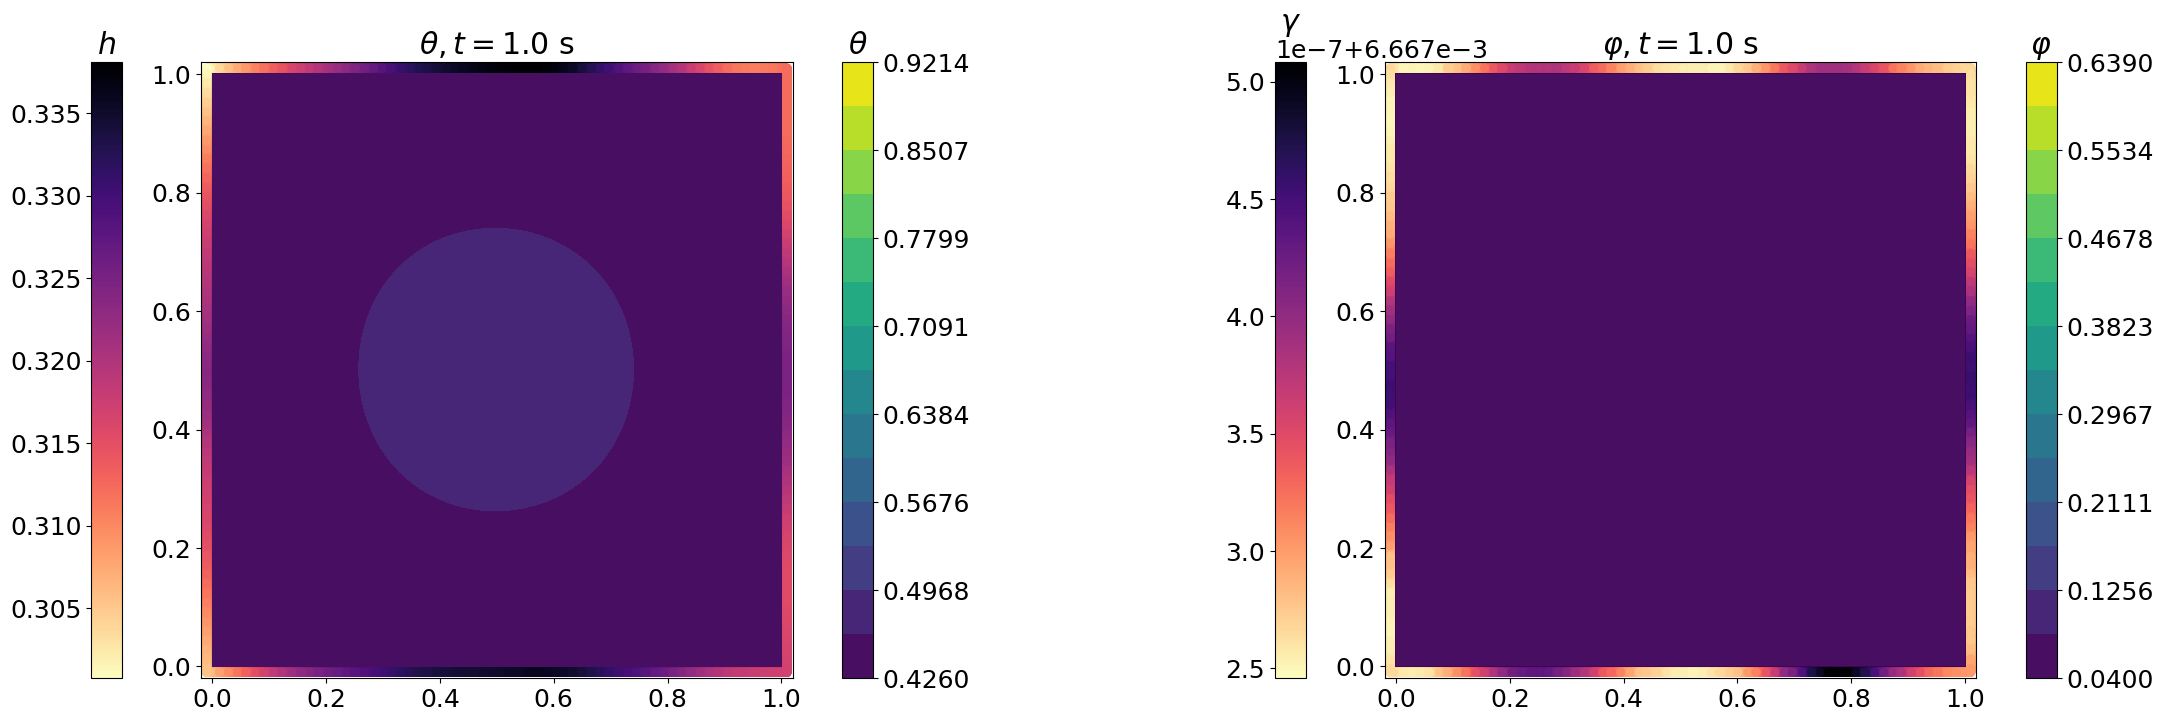

It: 13050 Time: 7.9219231605529785 loss_w: 0.00108693202 loss: 0.000160538373 J 0.000760218885
It: 13100 Time: 5.589023113250732 loss_w: 0.00108788512 loss: 0.000160100433 J 0.000761565927
It: 13150 Time: 5.580437898635864 loss_w: 0.00108814193 loss: 0.000159250223 J 0.000762944575
It: 13200 Time: 5.689420461654663 loss_w: 0.00108731957 loss: 0.000158136274 J 0.000763485674
It: 13250 Time: 5.690447807312012 loss_w: 0.00109271146 loss: 0.000160377676 J 0.000765024452
It: 13300 Time: 5.7501139640808105 loss_w: 0.00109718414 loss: 0.000162610668 J 0.000765562523
It: 13350 Time: 5.681389570236206 loss_w: 0.00109738053 loss: 0.000161603777 J 0.000766899146
It: 13400 Time: 5.4941558837890625 loss_w: 0.00108884787 loss: 0.000156007489 J 0.000767297752
It: 13450 Time: 5.657409906387329 loss_w: 0.00108797452 loss: 0.000154370966 J 0.000768991245
It: 13500 Time: 5.62350058555603 loss_w: 0.0010873588 loss: 0.000153066125 J 0.000770148297
It: 13550 Time: 5.586491823196411 loss_w: 0.00108693552 los

<Figure size 640x480 with 0 Axes>

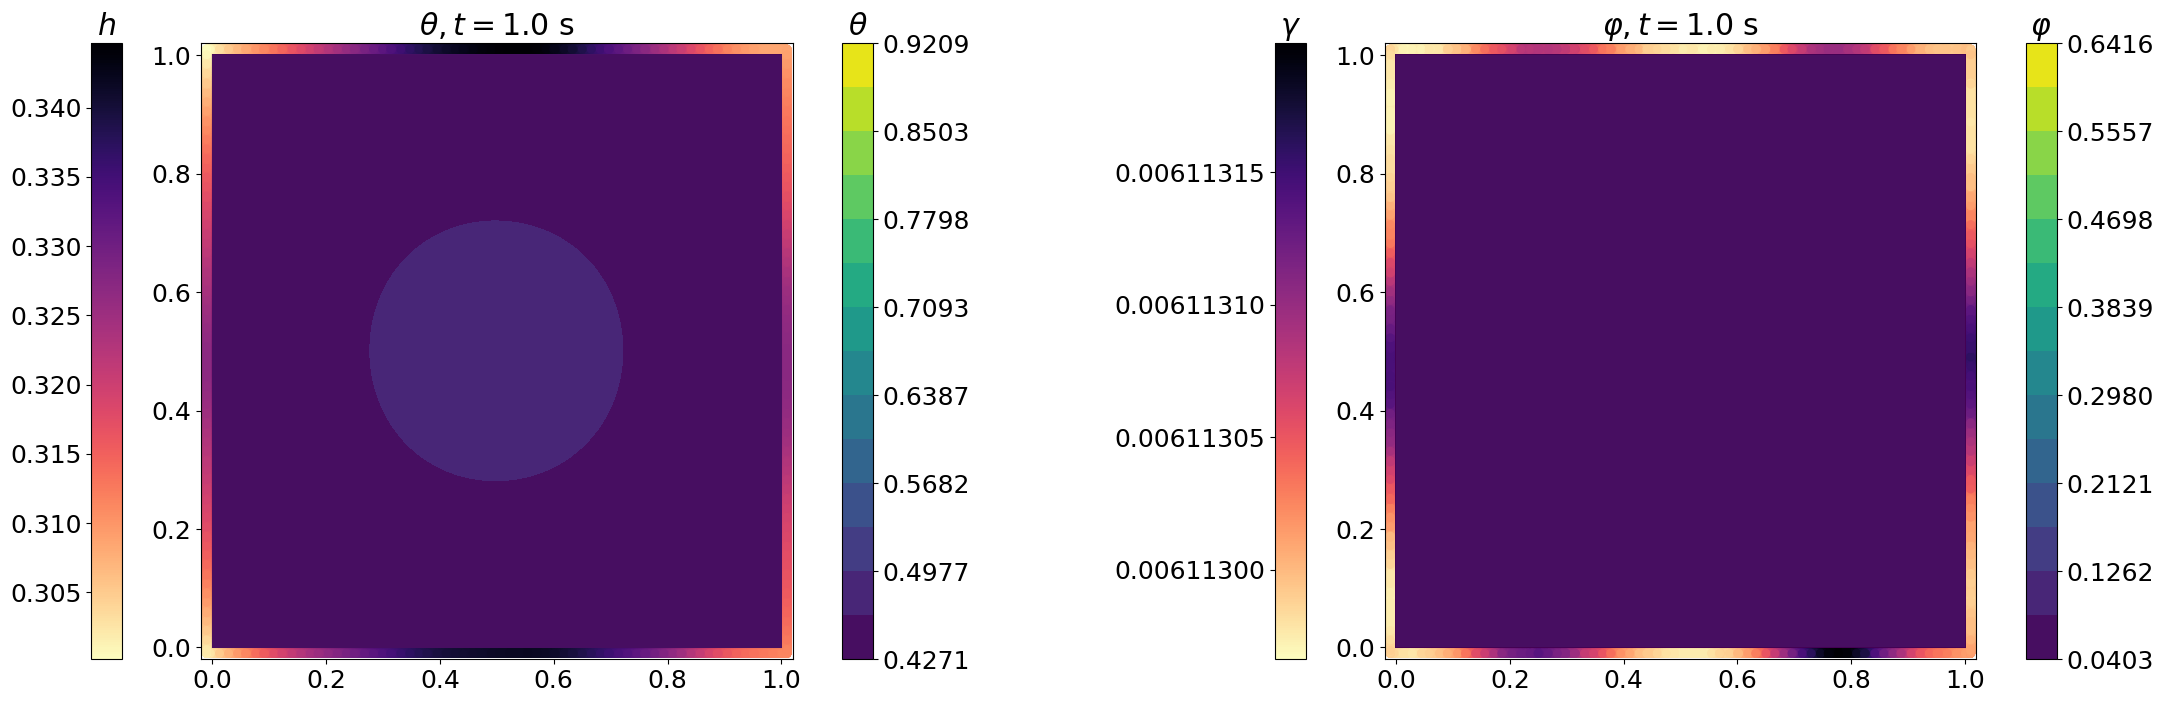

It: 14050 Time: 7.870450019836426 loss_w: 0.00108880526 loss: 0.000145229133 J 0.000781246461
It: 14100 Time: 5.517799615859985 loss_w: 0.00109513325 loss: 0.000148601466 J 0.000781367125
It: 14150 Time: 5.4998414516448975 loss_w: 0.00108907814 loss: 0.000145154874 J 0.000780991
It: 14200 Time: 5.518205165863037 loss_w: 0.00110895268 loss: 0.000155304384 J 0.000783224648
It: 14250 Time: 5.652727842330933 loss_w: 0.00109324651 loss: 0.000145453465 J 0.000783834199
It: 14300 Time: 5.70090126991272 loss_w: 0.00109546597 loss: 0.000145829501 J 0.000785079959
It: 14350 Time: 5.572166204452515 loss_w: 0.00109549519 loss: 0.000145189697 J 0.00078568497
It: 14400 Time: 5.624833106994629 loss_w: 0.00109128561 loss: 0.000141866287 J 0.000786672521
It: 14450 Time: 5.565193176269531 loss_w: 0.00109372532 loss: 0.000142190271 J 0.00078806869
It: 14500 Time: 5.535124063491821 loss_w: 0.00109201414 loss: 0.00014074886 J 0.000788613223
It: 14550 Time: 5.548110246658325 loss_w: 0.00109208829 loss: 0.00

<Figure size 640x480 with 0 Axes>

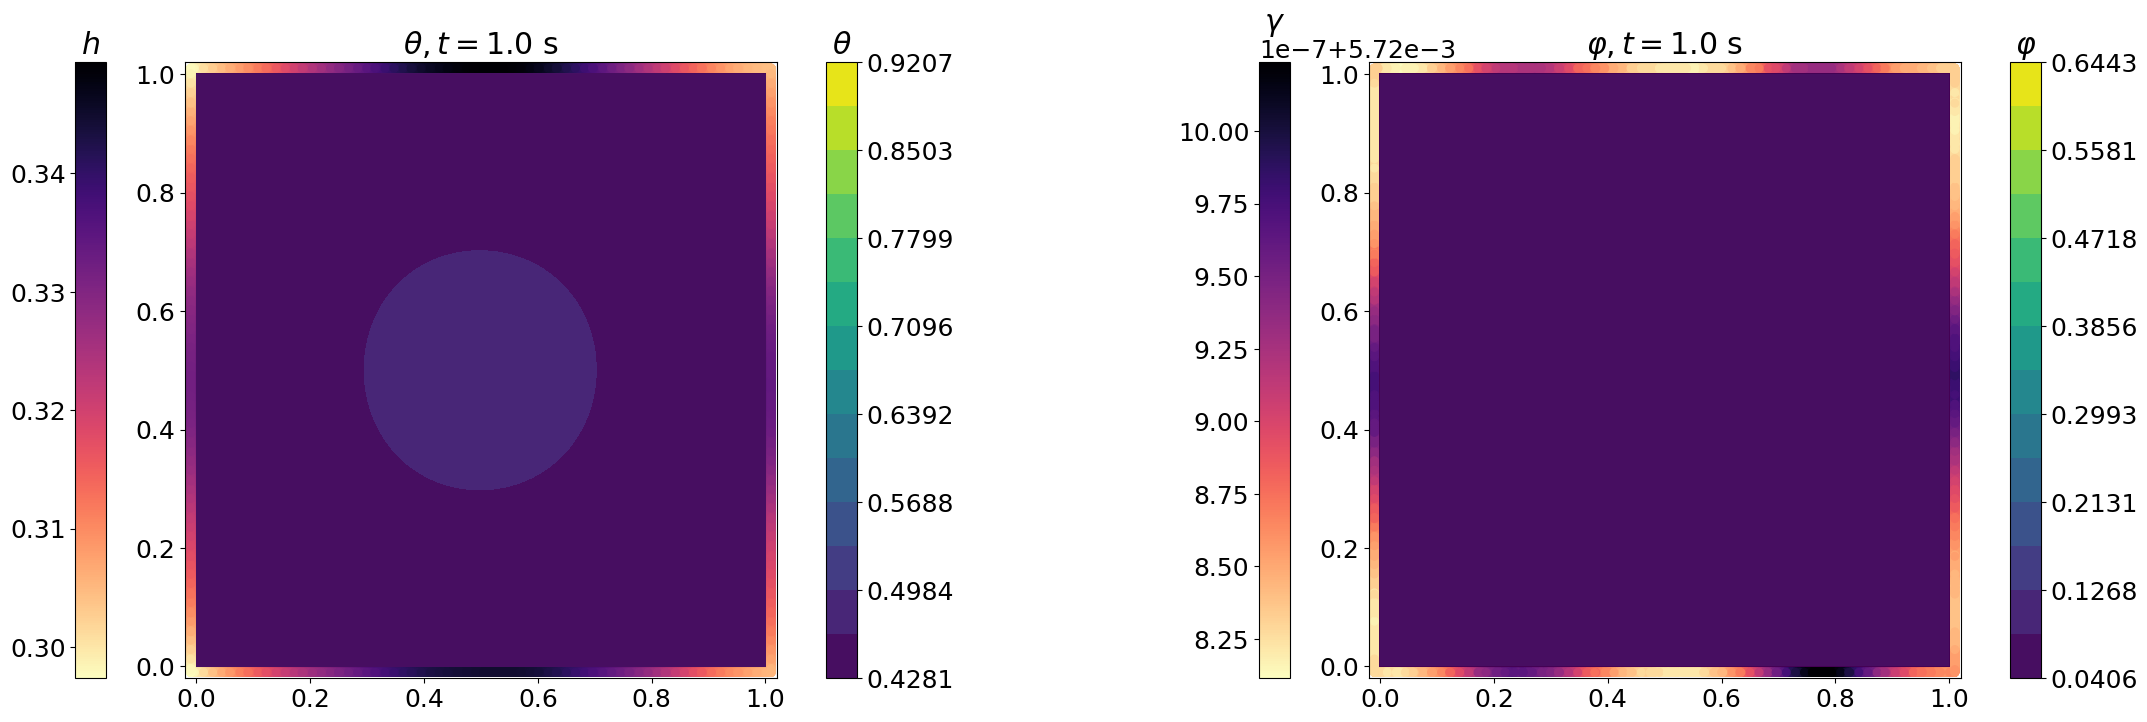

It: 15050 Time: 7.774639844894409 loss_w: 0.00110099767 loss: 0.000137989715 J 0.00079808291
It: 15100 Time: 5.526896715164185 loss_w: 0.0010986682 loss: 0.000135781287 J 0.000799524307
It: 15150 Time: 5.5355284214019775 loss_w: 0.00109922304 loss: 0.000135689799 J 0.000799627451
It: 15200 Time: 5.509032726287842 loss_w: 0.00110040396 loss: 0.000135476119 J 0.000800877751
It: 15250 Time: 5.515878915786743 loss_w: 0.00109987613 loss: 0.000134737158 J 0.000801116403
It: 15300 Time: 5.539069652557373 loss_w: 0.00109943864 loss: 0.000133350288 J 0.000802685798
It: 15350 Time: 5.576013803482056 loss_w: 0.00110007776 loss: 0.000133349546 J 0.000803059957
It: 15400 Time: 5.532927513122559 loss_w: 0.00110122026 loss: 0.000133125359 J 0.000804375159
It: 15450 Time: 5.564692497253418 loss_w: 0.00110354403 loss: 0.000133798065 J 0.000804840587
It: 15500 Time: 5.528954982757568 loss_w: 0.00110067835 loss: 0.00013166909 J 0.000805541873
It: 15550 Time: 5.54350209236145 loss_w: 0.00110168662 loss: 0

<Figure size 640x480 with 0 Axes>

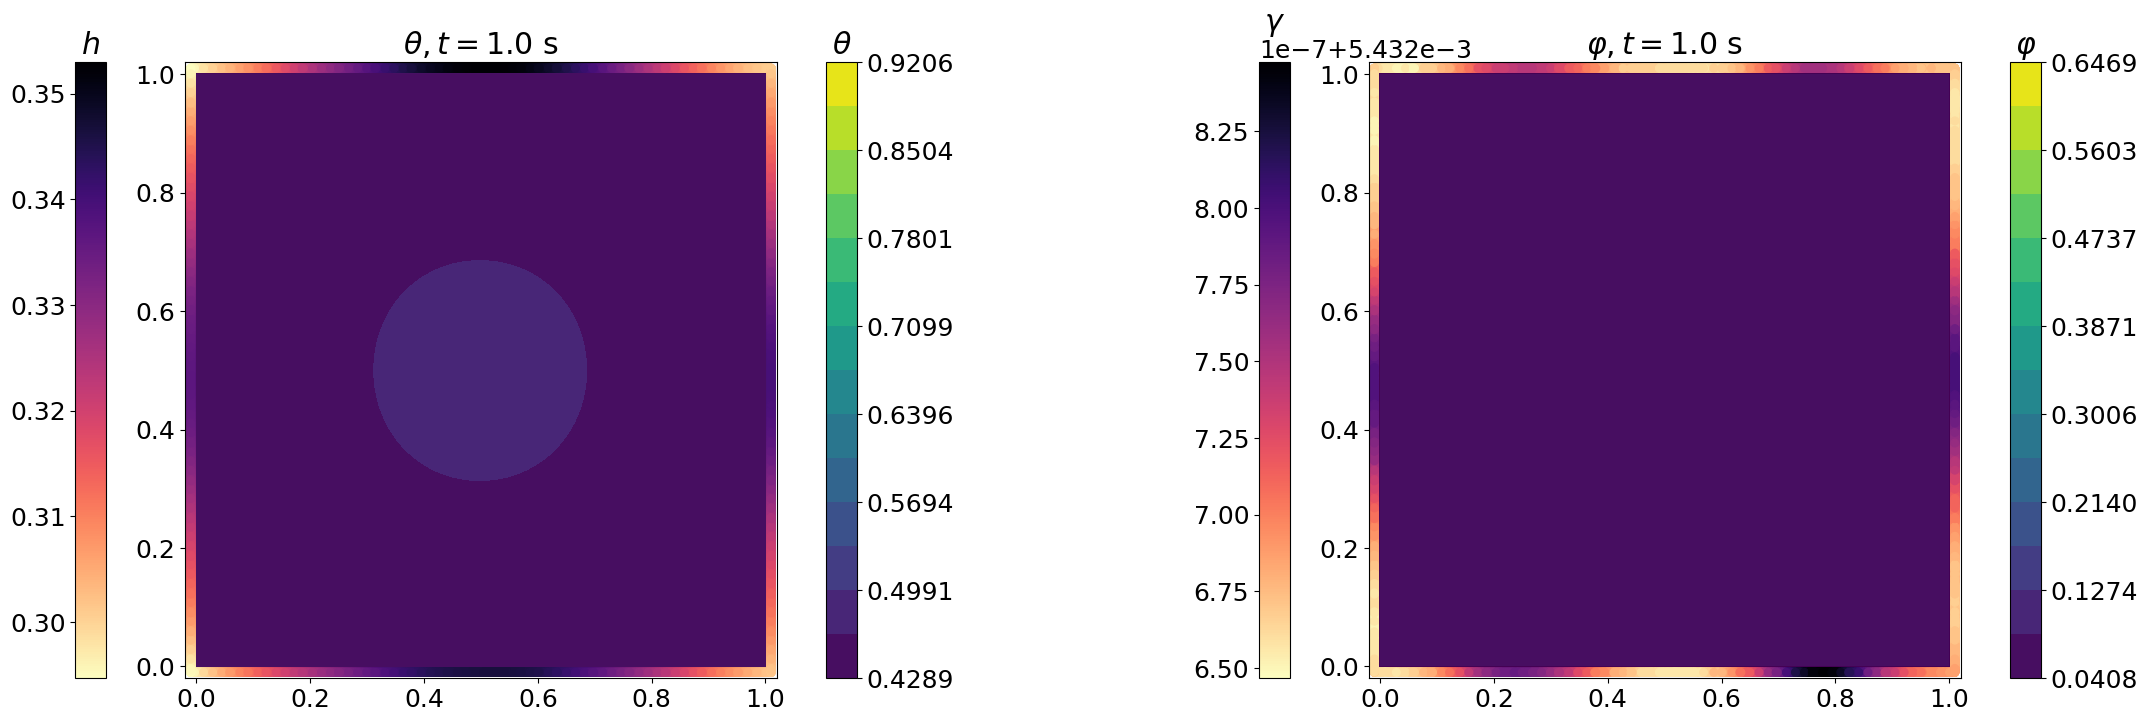

It: 16050 Time: 7.835475444793701 loss_w: 0.00110801356 loss: 0.000128708169 J 0.000814214116
It: 16100 Time: 5.586519956588745 loss_w: 0.00110576279 loss: 0.000127117601 J 0.000814336119
It: 16150 Time: 5.584313869476318 loss_w: 0.00110579503 loss: 0.000126897619 J 0.000814772502
It: 16200 Time: 5.566160440444946 loss_w: 0.00111001194 loss: 0.000127832202 J 0.000816871179
It: 16250 Time: 5.5605645179748535 loss_w: 0.00110583834 loss: 0.000125344304 J 0.000816644344
It: 16300 Time: 5.547033309936523 loss_w: 0.0011165645 loss: 0.000130683489 J 0.000817452557
It: 16350 Time: 5.506859540939331 loss_w: 0.00111604191 loss: 0.00012996771 J 0.000818053784
It: 16400 Time: 5.551781415939331 loss_w: 0.00111393584 loss: 0.000128216241 J 0.000818793371
It: 16450 Time: 5.598134279251099 loss_w: 0.00110920682 loss: 0.000124926315 J 0.000819756358
It: 16500 Time: 5.5291972160339355 loss_w: 0.00110788888 loss: 0.000123664548 J 0.000820224639
It: 16550 Time: 5.501241445541382 loss_w: 0.00111261511 loss

<Figure size 640x480 with 0 Axes>

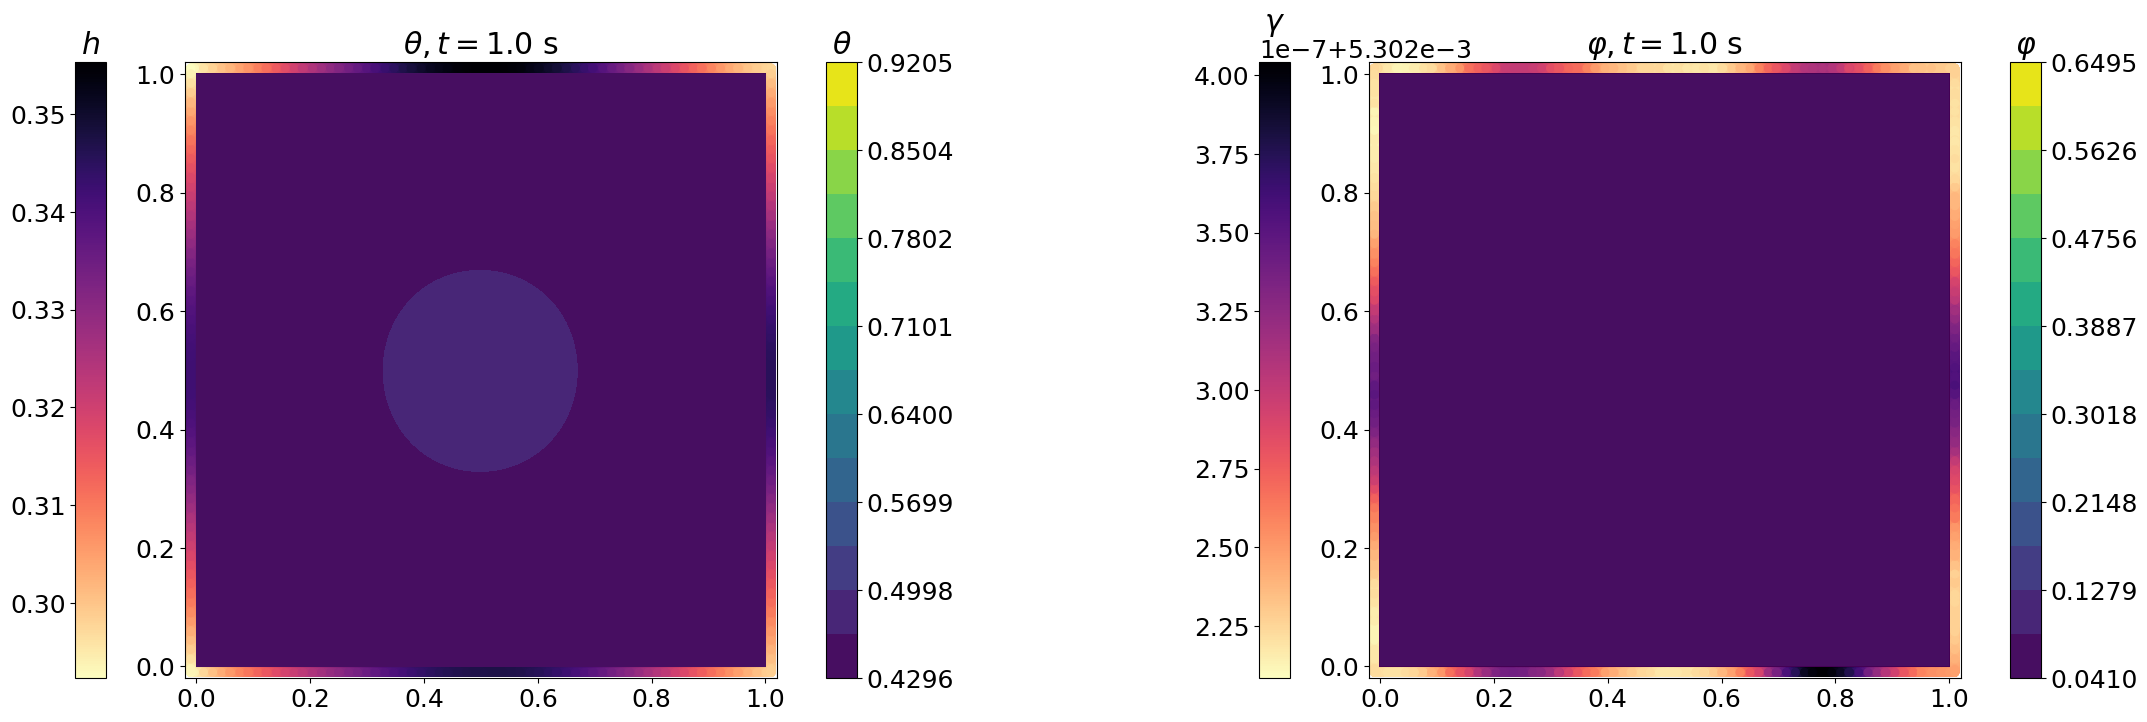

It: 17050 Time: 7.8772132396698 loss_w: 0.00111441128 loss: 0.000120921293 J 0.000828099961
It: 17100 Time: 5.6078691482543945 loss_w: 0.00111063162 loss: 0.00011857097 J 0.000828584481
It: 17150 Time: 5.575815677642822 loss_w: 0.00111097516 loss: 0.000118237076 J 0.000828899676
It: 17200 Time: 5.583004474639893 loss_w: 0.00111304165 loss: 0.000119002063 J 0.000829621451
It: 17250 Time: 5.558225631713867 loss_w: 0.00111126155 loss: 0.000117738455 J 0.000829413591
It: 17300 Time: 5.617136001586914 loss_w: 0.00111184036 loss: 0.000117445205 J 0.000830384612
It: 17350 Time: 5.60880708694458 loss_w: 0.00111182895 loss: 0.000117369265 J 0.000830457
It: 17400 Time: 5.68042778968811 loss_w: 0.00111151778 loss: 0.000116588992 J 0.000831380079
It: 17450 Time: 5.556585311889648 loss_w: 0.00111359474 loss: 0.000117445481 J 0.000831529
It: 17500 Time: 5.666203737258911 loss_w: 0.00111223327 loss: 0.000116628791 J 0.000831613783
It: 17550 Time: 5.5841286182403564 loss_w: 0.00111431768 loss: 0.00011

<Figure size 640x480 with 0 Axes>

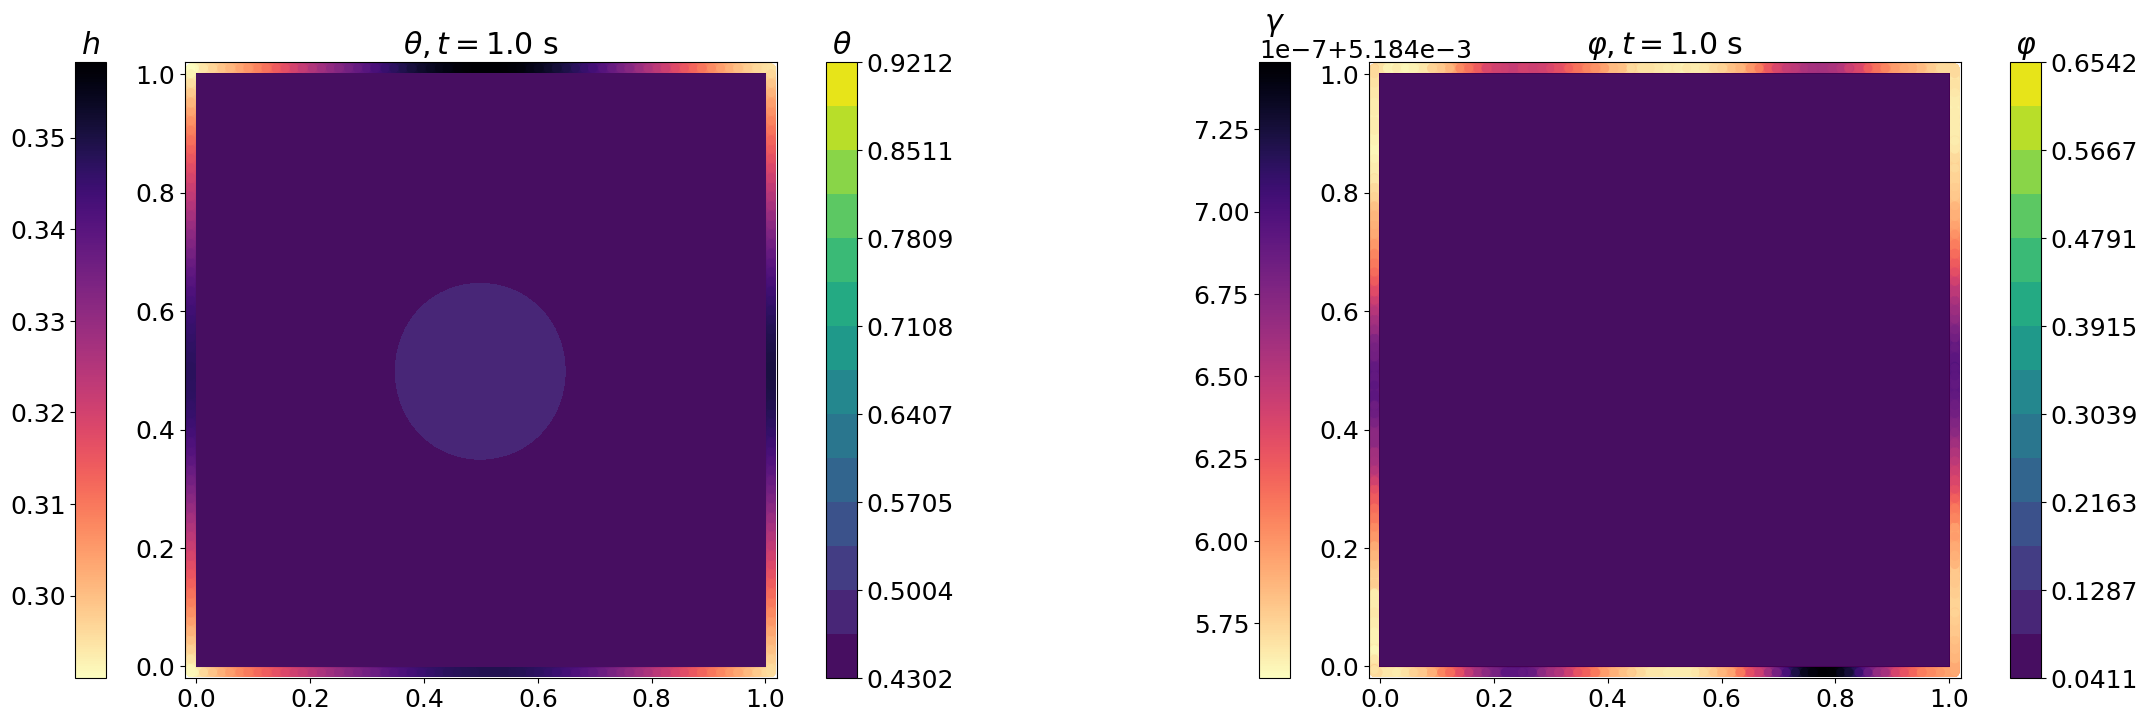

It: 18050 Time: 9.556498050689697 loss_w: 0.00111492351 loss: 0.000112894777 J 0.000837945438
It: 18100 Time: 5.507875204086304 loss_w: 0.0011141086 loss: 0.000112433125 J 0.000837463653
It: 18150 Time: 5.550277471542358 loss_w: 0.00111438334 loss: 0.000111769943 J 0.000838814594
It: 18200 Time: 5.573086738586426 loss_w: 0.00111343293 loss: 0.00011167147 J 0.000837829721
It: 18250 Time: 5.63519811630249 loss_w: 0.00111769699 loss: 0.000113698916 J 0.000837933
It: 18300 Time: 5.8142030239105225 loss_w: 0.00112938683 loss: 0.000119777862 J 0.000838354172
It: 18350 Time: 5.749345064163208 loss_w: 0.00111273059 loss: 0.000110535286 J 0.000838230073
It: 18400 Time: 5.770715236663818 loss_w: 0.00112194964 loss: 0.000115175812 J 0.000838415697
It: 18450 Time: 5.673851490020752 loss_w: 0.00111683249 loss: 0.000112130976 J 0.000838655513
It: 18500 Time: 5.538029909133911 loss_w: 0.00111754704 loss: 0.000112189038 J 0.000839375891
It: 18550 Time: 5.6167402267456055 loss_w: 0.00111225853 loss: 0.

<Figure size 640x480 with 0 Axes>

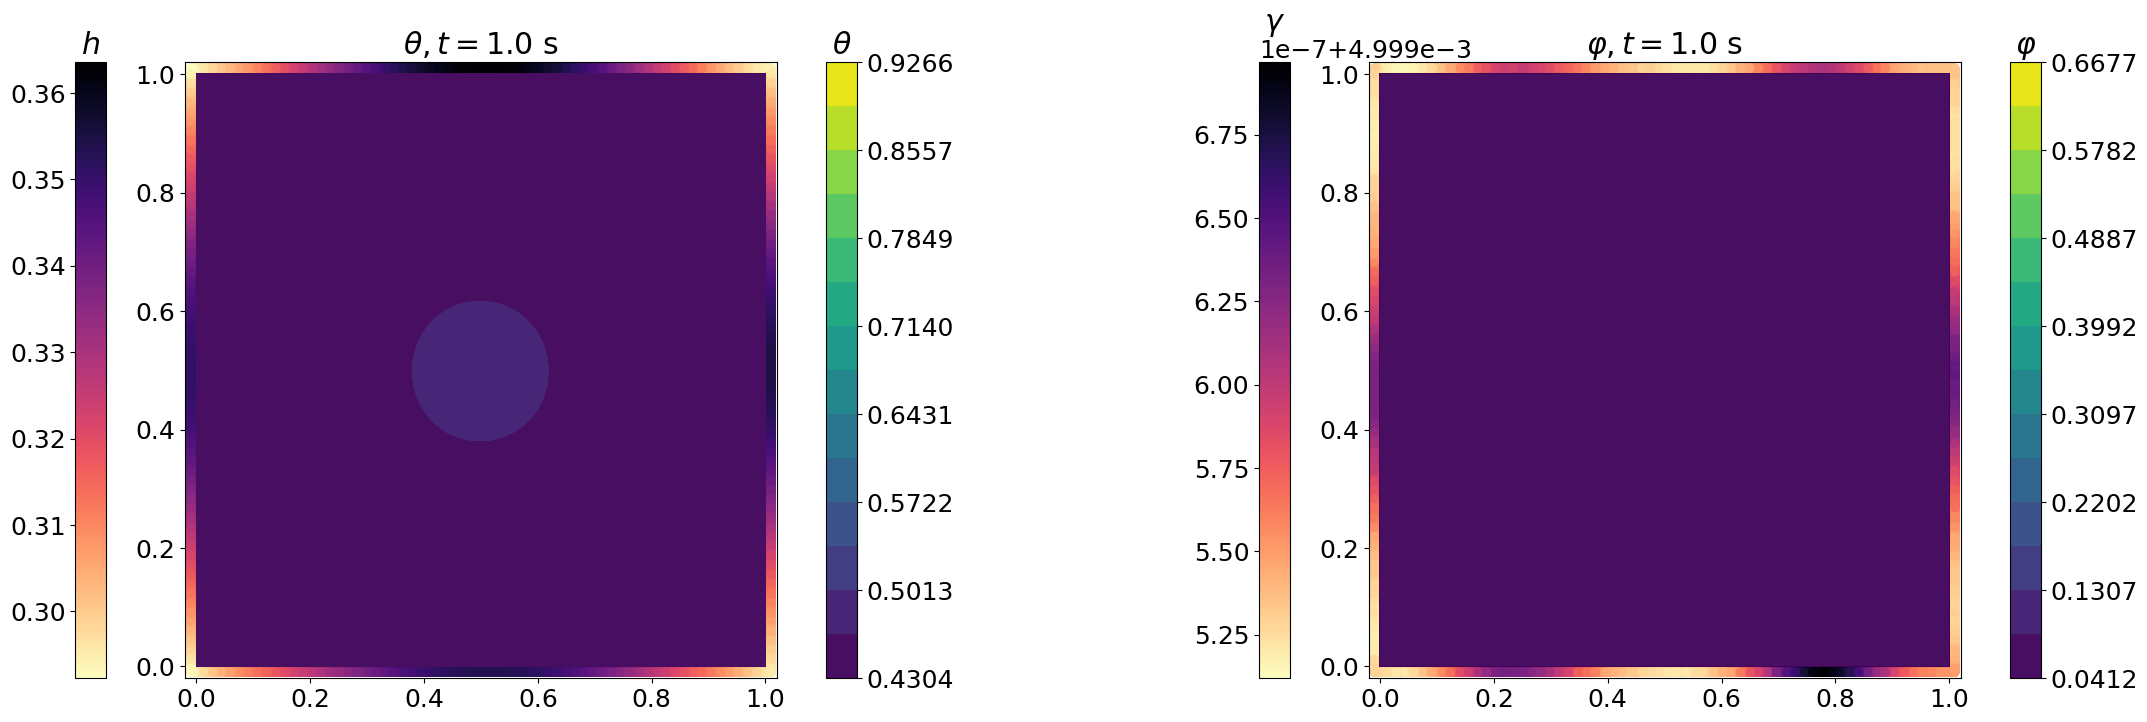

It: 19050 Time: 7.901513576507568 loss_w: 0.00110716547 loss: 0.000107777756 J 0.000833981438
It: 19100 Time: 5.565270662307739 loss_w: 0.00110396405 loss: 0.000106845437 J 0.00083247741
It: 19150 Time: 5.5145158767700195 loss_w: 0.00110554486 loss: 0.000108209882 J 0.000831337


KeyboardInterrupt: 

In [19]:
train.fit(30000)

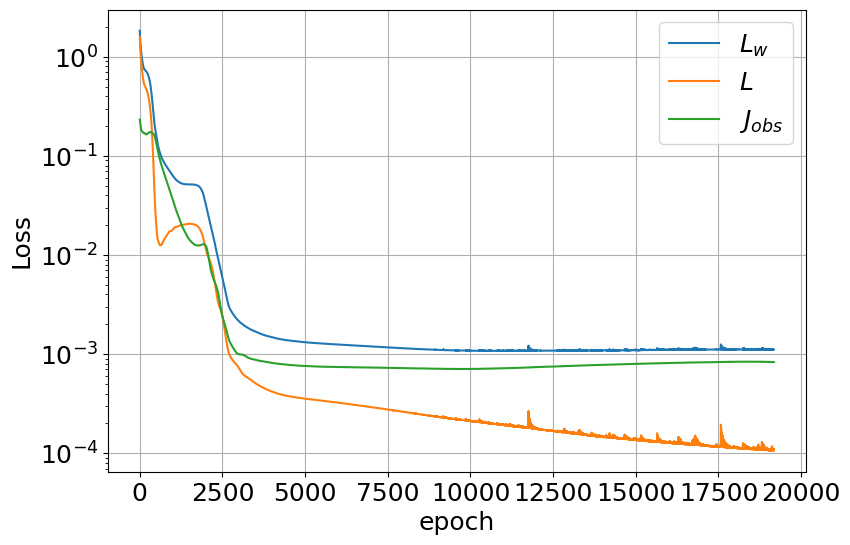

In [28]:
vis.plothist(train.hist1,train.hist2,train.hist3,save=False,path=None)

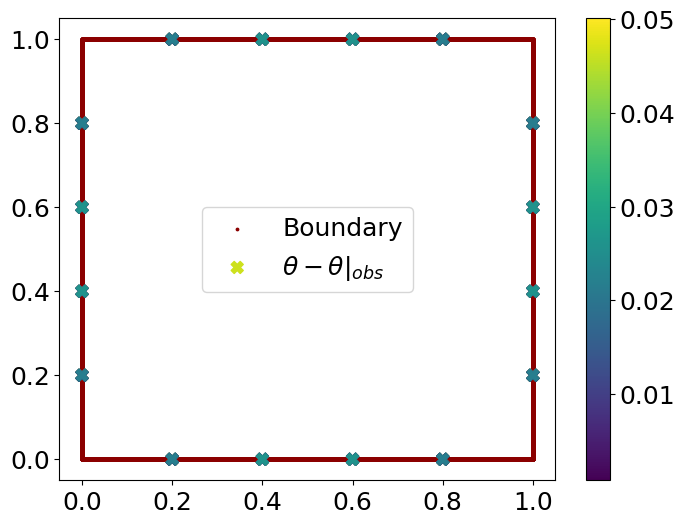

In [40]:
vis.plot_obs(save=False,path="")